# Preprocesamiento

In [2]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

import logging
from botocore.config import Config

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)

s3 = boto3.client(
    "s3",
    config=Config(
        connect_timeout=10,
        read_timeout=60,
        retries={"max_attempts": 3}
    )
)

BUCKET = "taller-datos-weather"

SILVER_DATASET_PREFIX = "silver/dataset_unificado/"

def leer_dataset_unificado(bucket, prefix):
    paginator = s3.get_paginator("list_objects_v2")
    keys = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            keys.append(obj["Key"])
    
    if not keys:
        logger.info(f"No hay archivos en s3://{bucket}/{prefix}")
        return pd.DataFrame()
    
    logger.info(f"Leyendo {len(keys)} archivo(s) desde s3://{bucket}/{prefix}")
    dfs = []
    for key in keys:
        response = s3.get_object(Bucket=bucket, Key=key)
        data = response["Body"].read()
        df = pd.read_parquet(BytesIO(data))
        logger.info(f"Leído OK: {len(df)} filas desde {key}")
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]

df = leer_dataset_unificado(BUCKET, SILVER_DATASET_PREFIX)

2026-06-05 20:27:48,856 | INFO | Leyendo 1 archivo(s) desde s3://taller-datos-weather/silver/dataset_unificado/
2026-06-05 20:27:54,301 | INFO | Leído OK: 2527807 filas desde silver/dataset_unificado/20260530_232320_00268_ngbd2_32314f71-d6a1-4993-b033-9e244d056272


In [3]:
df.head(2)

,station_id,fecha_hora,latitude,longitude,time_obs,time_fcst,fcst_is_daytime,fcst_temperature_celsius,fcst_dewpoint_celsius,fcst_relative_humidity_pct,...,obs_dewpoint_celsius,obs_relative_humidity_pct,obs_wind_speed_ms,obs_wind_gust_ms,obs_precipitation_last_hour_m,obs_visibility_m,obs_barometric_pressure_pa,obs_sea_level_pressure_pa,forecast_origen,observacion_origen
0,KPIB,2026-01-06 14:00:00,31.4667,-89.3333,2026-01-06 14:00:00,2026-01-06 14:00:00,None,16.1,15.3,95.0,...,15.7,97.0,3.04,5.5,0.0,NaN,100590.0,101640.0,Históricos,Históricos
1,KPIB,2026-01-06 23:00:00,31.4667,-89.3333,2026-01-06 23:00:00,2026-01-06 23:00:00,None,22.8,16.1,66.0,...,15.4,65.0,3.26,6.4,0.0,NaN,100270.0,101290.0,Históricos,Históricos


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527807 entries, 0 to 2527806
Data columns (total 26 columns):
 #   Column                                 Dtype         
---  ------                                 -----         
 0   station_id                             object        
 1   fecha_hora                             datetime64[ns]
 2   latitude                               float64       
 3   longitude                              float64       
 4   time_obs                               datetime64[ns]
 5   time_fcst                              datetime64[ns]
 6   fcst_is_daytime                        object        
 7   fcst_temperature_celsius               float64       
 8   fcst_dewpoint_celsius                  float64       
 9   fcst_relative_humidity_pct             float64       
 10  fcst_probability_of_precipitation_pct  float64       
 11  fcst_wind_speed_ms                     float64       
 12  fcst_wind_direction                    object        
 1

In [5]:
df[[ 'latitude' , 'longitude', "obs_relative_humidity_pct", "fcst_relative_humidity_pct"]].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527807 entries, 0 to 2527806
Data columns (total 4 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   latitude                    2527807 non-null  float64
 1   longitude                   2527807 non-null  float64
 2   obs_relative_humidity_pct   2461847 non-null  float64
 3   fcst_relative_humidity_pct  2398011 non-null  float64
dtypes: float64(4)
memory usage: 77.1 MB


In [6]:
df["error_humedad"] = df["obs_relative_humidity_pct"] - df["fcst_relative_humidity_pct"]

In [7]:
df[[ 'latitude' , 'longitude', "obs_relative_humidity_pct", "fcst_relative_humidity_pct", 'error_humedad']].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527807 entries, 0 to 2527806
Data columns (total 5 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   latitude                    2527807 non-null  float64
 1   longitude                   2527807 non-null  float64
 2   obs_relative_humidity_pct   2461847 non-null  float64
 3   fcst_relative_humidity_pct  2398011 non-null  float64
 4   error_humedad               2343676 non-null  float64
dtypes: float64(5)
memory usage: 96.4 MB


In [8]:
df = df.dropna(subset=["error_humedad"]).reset_index(drop=True)
df[[ 'latitude' , 'longitude', "obs_relative_humidity_pct", "fcst_relative_humidity_pct", 'error_humedad']].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2343676 entries, 0 to 2343675
Data columns (total 5 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   latitude                    2343676 non-null  float64
 1   longitude                   2343676 non-null  float64
 2   obs_relative_humidity_pct   2343676 non-null  float64
 3   fcst_relative_humidity_pct  2343676 non-null  float64
 4   error_humedad               2343676 non-null  float64
dtypes: float64(5)
memory usage: 89.4 MB


In [9]:
df_estaciones = df.groupby("station_id").agg({
    "error_humedad": "mean",
    "obs_temperature_celsius": "mean",
    "longitude": "mean",
    "latitude": "mean"
})

In [10]:

df_estaciones[[ 'latitude' , 'longitude',  'error_humedad']].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, KAAF to KZZV
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       500 non-null    float64
 1   longitude      500 non-null    float64
 2   error_humedad  500 non-null    float64
dtypes: float64(3)
memory usage: 15.6+ KB


# Graficos de Errores

## Error en Latitud

Text(0.5, 1.0, 'Error de Humedad vs Latitud con Regresión Lineal')

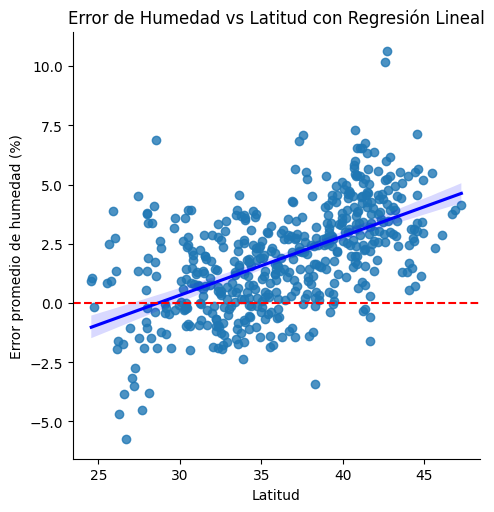

In [11]:

sns.lmplot(x='latitude', y='error_humedad', data=df_estaciones,  line_kws={'color': 'blue'})
plt.axhline(0, color='red', linestyle='--', label='Error = 0')
plt.xlabel("Latitud")
plt.ylabel("Error promedio de humedad (%)")
plt.title("Error de Humedad vs Latitud con Regresión Lineal")

## Error en Longitud

Text(0.5, 1.0, 'Error de Humedad vs Longitud con Regresión Lineal')

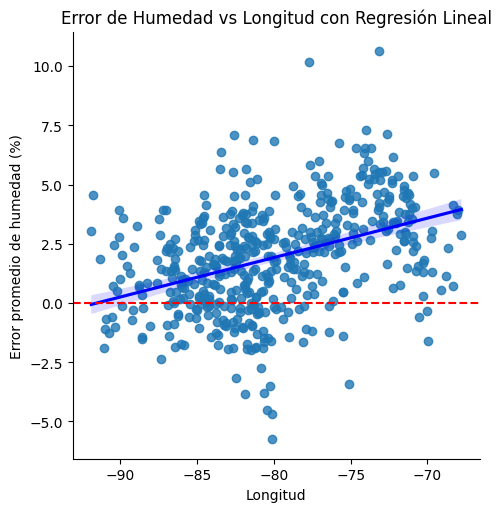

In [12]:
sns.lmplot(x='longitude', y='error_humedad', data=df_estaciones,  line_kws={'color': 'blue'})
plt.axhline(0, color='red', linestyle='--', label='Error = 0')
plt.xlabel("Longitud")
plt.ylabel("Error promedio de humedad (%)")
plt.title("Error de Humedad vs Longitud con Regresión Lineal")

## Error en Longitud y Latitud

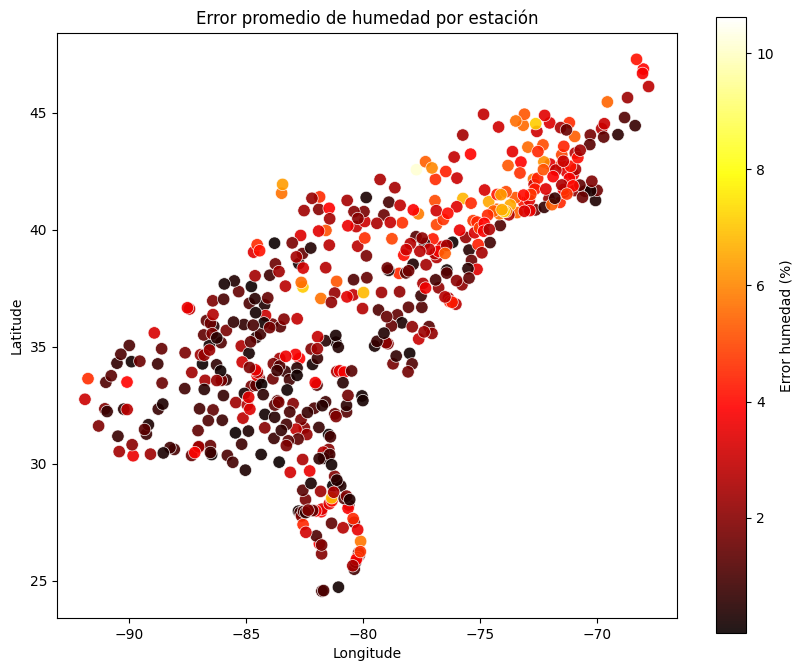

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df_estaciones['longitude'],
    df_estaciones['latitude'],
    c=abs(df_estaciones['error_humedad']),
    cmap='hot',
    s=80,
    edgecolors='w',
    linewidths=0.5,
    alpha=0.9
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Error promedio de humedad por estación")
ax.set_aspect('equal', adjustable='box')
plt.colorbar(sc, ax=ax, label="Error humedad (%)")
plt.show()

## Error por Hora del dia

In [14]:
df["Hora"] = df["fecha_hora"].dt.hour

In [15]:
df_horarios = df.groupby("Hora").agg({
    "error_humedad": "mean"}).reset_index()

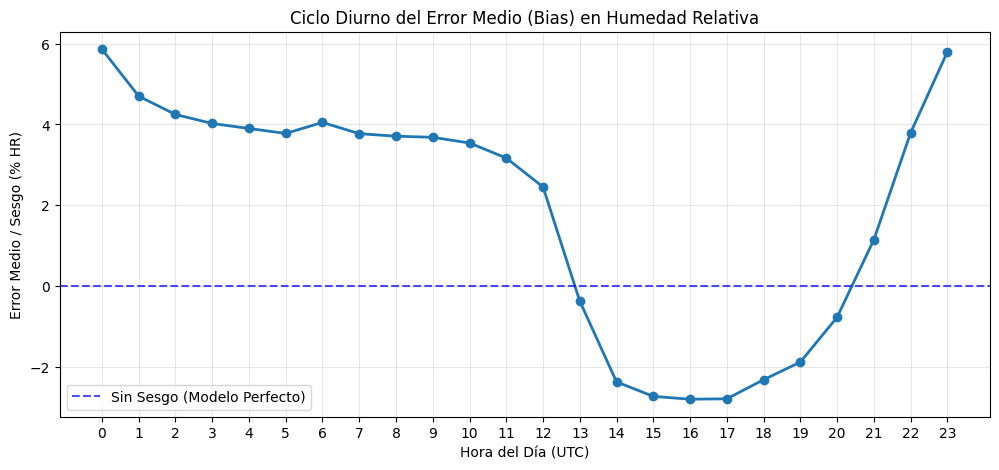

In [16]:
x = df_horarios["Hora"]
y = df_horarios["error_humedad"]

# Figura
plt.figure(figsize=(12,5))

plt.plot(x,y,marker='o',linewidth=2)

plt.axhline(y=0,color='blue',linestyle='--',alpha=0.7,label='Sin Sesgo (Modelo Perfecto)')

# Títulos y etiquetas
plt.title("Ciclo Diurno del Error Medio (Bias) en Humedad Relativa")
plt.xlabel("Hora del Día (UTC)")
plt.ylabel("Error Medio / Sesgo (% HR)")

# Grilla
plt.grid(True, alpha=0.3)

# Mostrar todas las horas
plt.xticks(range(24))

# Leyenda
plt.legend()

plt.show()

# Modelo 

In [17]:
df_modelo = df[["station_id","fecha_hora","Hora","error_humedad","obs_temperature_celsius","obs_wind_speed_ms","obs_precipitation_last_hour_m","obs_sea_level_pressure_pa","longitude","latitude","observacion_origen"]].copy()


In [18]:
df_modelo.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2343676 entries, 0 to 2343675
Data columns (total 11 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   station_id                     2343676 non-null  object        
 1   fecha_hora                     2343676 non-null  datetime64[ns]
 2   Hora                           2343676 non-null  int32         
 3   error_humedad                  2343676 non-null  float64       
 4   obs_temperature_celsius        2343676 non-null  float64       
 5   obs_wind_speed_ms              2330943 non-null  float64       
 6   obs_precipitation_last_hour_m  2070112 non-null  float64       
 7   obs_sea_level_pressure_pa      2090413 non-null  float64       
 8   longitude                      2343676 non-null  float64       
 9   latitude                       2343676 non-null  float64       
 10  observacion_origen             2343676 non-null  objec

In [19]:
df_modelo["fecha_hora"].min(), df_modelo["fecha_hora"].max()

(Timestamp('2025-10-27 00:00:00'), Timestamp('2026-05-30 21:00:00'))

In [20]:
# Ordenar por estación y tiempo (necesario para el lag)
df_modelo = df_modelo.sort_values(["station_id", "fecha_hora"]).reset_index(drop=True)

# Definir el corte temporal (percentil 80)
fecha_corte = df_modelo["fecha_hora"].quantile(0.8)
print(f"Fecha de corte: {fecha_corte}")
print(f"Train: {(df_modelo['fecha_hora'] <= fecha_corte).sum():,} filas")
print(f"Test:  {(df_modelo['fecha_hora'] >  fecha_corte).sum():,} filas")

Fecha de corte: 2026-04-01 05:00:00
Train: 1,875,000 filas
Test:  468,676 filas


## Benchmark: pronostico que que el error actual será el error promedio de esa estacion en ese horario

Calcular el promedio de error por estación + hora (solo en train)

In [21]:
# Definir máscaras de train/test
mask_train = df_modelo["fecha_hora"] <= fecha_corte
mask_test  = df_modelo["fecha_hora"] >  fecha_corte

# Calcular promedio de error_humedad por (station_id, Hora) usando SOLO train
promedio_estacion_hora = (
    df_modelo.loc[mask_train]
    .groupby(["station_id", "Hora"], observed=True)["error_humedad"]
    .mean()
    .rename("pred_benchmark")
    .reset_index()
)

print(f"Combinaciones (estación, hora) en train: {len(promedio_estacion_hora):,}")
print(promedio_estacion_hora.head())

Combinaciones (estación, hora) en train: 12,000
  station_id  Hora  pred_benchmark
0       KAAF     0        3.592357
1       KAAF     1        2.203822
2       KAAF     2        1.681529
3       KAAF     3        1.770701
4       KAAF     4        1.318471


 Asignar la predicción del benchmark a todo el df

In [22]:
df_modelo = df_modelo.merge(
    promedio_estacion_hora,
    on=["station_id", "Hora"],
    how="left"
)

# Chequear nulos (pueden aparecer si en test hay combinaciones estación-hora que no están en train)
nulos = df_modelo.loc[mask_test, "pred_benchmark"].isna().sum()
print(f"Nulos en pred_benchmark sobre test: {nulos:,}")

Nulos en pred_benchmark sobre test: 0


Evaluar el benchmark (RMSE + MAE sobre test)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = df_modelo.loc[mask_test, "error_humedad"]
y_pred_bench = df_modelo.loc[mask_test, "pred_benchmark"]

rmse_bench = np.sqrt(mean_squared_error(y_test, y_pred_bench))
mae_bench  = mean_absolute_error(y_test, y_pred_bench)

print(f"📊 Benchmark (promedio por estación + hora)")
print(f"   RMSE: {rmse_bench:.4f}")
print(f"   MAE:  {mae_bench:.4f}")

📊 Benchmark (promedio por estación + hora)
   RMSE: 9.3241
   MAE:  7.1109


## Modelo 1

Preparar features para CatBoost

In [24]:
features = [
    "station_id",
    "Hora",
    "obs_temperature_celsius",
    "obs_wind_speed_ms",
    "obs_precipitation_last_hour_m",
    "obs_sea_level_pressure_pa",
    "longitude",
    "latitude",
]
cat_features = ["station_id"]
target = "error_humedad"

X_train = df_modelo.loc[mask_train, features]
y_train = df_modelo.loc[mask_train, target]

X_test = df_modelo.loc[mask_test, features]
y_test = df_modelo.loc[mask_test, target]

# CatBoost no acepta NaN en features categóricas, pero sí en numéricas
# Convertimos station_id a string para evitar problemas con el dtype category
X_train = X_train.copy()
X_test  = X_test.copy()
X_train["station_id"] = X_train["station_id"].astype(str)
X_test["station_id"]  = X_test["station_id"].astype(str)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nNulos en X_train por columna:")
print(X_train.isna().sum())

X_train: (1875000, 8)
X_test:  (468676, 8)

Nulos en X_train por columna:
station_id                       0
Hora                             0
obs_temperature_celsius          0
obs_wind_speed_ms                0
obs_precipitation_last_hour_m    0
obs_sea_level_pressure_pa        0
longitude                        0
latitude                         0
dtype: int64


Entrenar CatBoost 

In [25]:
import sys
import subprocess
from catboost import CatBoostRegressor, Pool

# Crear Pools (estructura de datos optimizada de CatBoost)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

modelo_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)

modelo_cat.fit(train_pool, eval_set=test_pool)

0:	learn: 6.9992922	test: 7.0139740	best: 7.0139740 (0)	total: 911ms	remaining: 15m 10s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 6.825377926
bestIteration = 23

Shrink model to first 24 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='MAE', random_seed=42, verbose=100)

Evaluar CatBoost vs Benchmark

In [26]:
y_pred_cat = modelo_cat.predict(X_test)

rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat  = mean_absolute_error(y_test, y_pred_cat)

# Tabla comparativa
print(f"{'Modelo':<35} {'RMSE':>10} {'MAE':>10}")
print("-" * 57)
print(f"{'Benchmark (prom. estación+hora)':<35} {rmse_bench:>10.4f} {mae_bench:>10.4f}")
print(f"{'CatBoost':<35} {rmse_cat:>10.4f} {mae_cat:>10.4f}")
print("-" * 57)
print(f"{'Mejora RMSE':<35} {(1 - rmse_cat/rmse_bench)*100:>9.2f}%")
print(f"{'Mejora MAE':<35} {(1 - mae_cat/mae_bench)*100:>9.2f}%")

Modelo                                    RMSE        MAE
---------------------------------------------------------
Benchmark (prom. estación+hora)         9.3241     7.1109
CatBoost                                8.9860     6.8254
---------------------------------------------------------
Mejora RMSE                              3.63%
Mejora MAE                               4.02%


## Modelo 1, de nuevo

Agregar features temporales (hora y mes como funcion trigonometrica)

In [27]:
# Features temporales derivadas de fecha_hora
df_modelo["mes"]          = df_modelo["fecha_hora"].dt.month
df_modelo["dia_semana"]   = df_modelo["fecha_hora"].dt.dayofweek  # 0=lunes, 6=domingo
df_modelo["dia_anio"]     = df_modelo["fecha_hora"].dt.dayofyear
df_modelo["semana_anio"]  = df_modelo["fecha_hora"].dt.isocalendar().week.astype(int)

# Encodings cíclicos para Hora y mes (para que el modelo entienda que hora 23 está cerca de hora 0)
df_modelo["hora_sin"] = np.sin(2 * np.pi * df_modelo["Hora"] / 24)
df_modelo["hora_cos"] = np.cos(2 * np.pi * df_modelo["Hora"] / 24)
df_modelo["mes_sin"]  = np.sin(2 * np.pi * df_modelo["mes"] / 12)
df_modelo["mes_cos"]  = np.cos(2 * np.pi * df_modelo["mes"] / 12)

print(df_modelo[["fecha_hora","Hora","mes","dia_semana","dia_anio","hora_sin","hora_cos","mes_sin","mes_cos"]].head())

           fecha_hora  Hora  mes  dia_semana  dia_anio  hora_sin  hora_cos  \
0 2025-10-27 00:00:00     0   10           0       300  0.000000  1.000000   
1 2025-10-27 01:00:00     1   10           0       300  0.258819  0.965926   
2 2025-10-27 02:00:00     2   10           0       300  0.500000  0.866025   
3 2025-10-27 03:00:00     3   10           0       300  0.707107  0.707107   
4 2025-10-27 04:00:00     4   10           0       300  0.866025  0.500000   

    mes_sin  mes_cos  
0 -0.866025      0.5  
1 -0.866025      0.5  
2 -0.866025      0.5  
3 -0.866025      0.5  
4 -0.866025      0.5  


Lag de error_humedad por estación (1 hora atrás)

In [28]:
# Importante: el df ya está ordenado por station_id y fecha_hora desde la Celda 1
df_modelo["error_humedad_lag1"] = (
    df_modelo.groupby("station_id", observed=True)["error_humedad"].shift(1)
)

# Lag de 24h (mismo horario del día anterior, aprox)
df_modelo["error_humedad_lag24"] = (
    df_modelo.groupby("station_id", observed=True)["error_humedad"].shift(24)
)

print(f"Nulos en lag1:  {df_modelo['error_humedad_lag1'].isna().sum():,}")
print(f"Nulos en lag24: {df_modelo['error_humedad_lag24'].isna().sum():,}")

Nulos en lag1:  500
Nulos en lag24: 12,000


Redefinir features y rearmar X_train / X_test

In [29]:
features = [
    "station_id",
    "Hora",
    "obs_temperature_celsius",
    "obs_wind_speed_ms",
    "obs_precipitation_last_hour_m",
    "obs_sea_level_pressure_pa",
    "longitude",
    "latitude",
    # nuevas features temporales
    "mes",
    "dia_semana",
    "dia_anio",
    "semana_anio",
    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos",
    # nuevas features de lag
    "error_humedad_lag1",
    "error_humedad_lag24",
]
cat_features = ["station_id"]
target = "error_humedad"

X_train = df_modelo.loc[mask_train, features].copy()
y_train = df_modelo.loc[mask_train, target]
X_test  = df_modelo.loc[mask_test,  features].copy()
y_test  = df_modelo.loc[mask_test,  target]

X_train["station_id"] = X_train["station_id"].astype(str)
X_test["station_id"]  = X_test["station_id"].astype(str)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (1875000, 18)
X_test:  (468676, 18)


Reentrenar CatBoost con las features nuevas

In [30]:
from catboost import CatBoostRegressor, Pool

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

modelo_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)

modelo_cat.fit(train_pool, eval_set=test_pool)

0:	learn: 6.6825570	test: 6.7056589	best: 6.7056589 (0)	total: 682ms	remaining: 11m 21s
100:	learn: 3.6285022	test: 4.5924614	best: 4.5910464 (94)	total: 1m 2s	remaining: 9m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4.590639817
bestIteration = 108

Shrink model to first 109 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='MAE', random_seed=42, verbose=100)

Comparacion con Benchmark

In [31]:
y_pred_cat = modelo_cat.predict(X_test)

rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat  = mean_absolute_error(y_test, y_pred_cat)

print(f"{'Modelo':<35} {'RMSE':>10} {'MAE':>10}")
print("-" * 57)
print(f"{'Benchmark (prom. estación+hora)':<35} {rmse_bench:>10.4f} {mae_bench:>10.4f}")
print(f"{'CatBoost (v1 - sin features temp)':<35} {14.4226:>10.4f} {'-':>10}")
print(f"{'CatBoost (v2 - con features temp)':<35} {rmse_cat:>10.4f} {mae_cat:>10.4f}")
print("-" * 57)
print(f"{'Mejora vs benchmark - RMSE':<35} {(1 - rmse_cat/rmse_bench)*100:>9.2f}%")
print(f"{'Mejora vs benchmark - MAE':<35} {(1 - mae_cat/mae_bench)*100:>9.2f}%")

Modelo                                    RMSE        MAE
---------------------------------------------------------
Benchmark (prom. estación+hora)         9.3241     7.1109
CatBoost (v1 - sin features temp)      14.4226          -
CatBoost (v2 - con features temp)       6.4187     4.5906
---------------------------------------------------------
Mejora vs benchmark - RMSE              31.16%
Mejora vs benchmark - MAE               35.44%


Feature Importance

In [32]:
import pandas as pd

importances = pd.DataFrame({
    "feature": features,
    "importance": modelo_cat.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.to_string(index=False))

                      feature  importance
           error_humedad_lag1   79.635357
                         Hora    6.936052
                     hora_cos    2.968571
          error_humedad_lag24    2.407195
                     hora_sin    2.341577
      obs_temperature_celsius    1.656027
obs_precipitation_last_hour_m    1.178755
            obs_wind_speed_ms    0.913963
                   station_id    0.536013
                      mes_sin    0.329084
                     latitude    0.269428
                     dia_anio    0.264466
                    longitude    0.211190
                  semana_anio    0.122888
                      mes_cos    0.090687
                          mes    0.065444
    obs_sea_level_pressure_pa    0.054211
                   dia_semana    0.019092


El modelo dice, basicamente, que el error se autocorrelaciona mucho con su valor anterior. Vamos a analizar eso:

## Modelo 1, de nuevo: CatBoost SIN features de lag. Para ver qué pasa

In [33]:
features_sin_lag = [f for f in features if f not in ["error_humedad_lag1", "error_humedad_lag24"]]

X_train_sl = df_modelo.loc[mask_train, features_sin_lag].copy()
X_test_sl  = df_modelo.loc[mask_test,  features_sin_lag].copy()
X_train_sl["station_id"] = X_train_sl["station_id"].astype(str)
X_test_sl["station_id"]  = X_test_sl["station_id"].astype(str)

train_pool_sl = Pool(X_train_sl, y_train, cat_features=cat_features)
test_pool_sl  = Pool(X_test_sl,  y_test,  cat_features=cat_features)

modelo_cat_sl = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)
modelo_cat_sl.fit(train_pool_sl, eval_set=test_pool_sl)

0:	learn: 6.9916053	test: 7.0147450	best: 7.0147450 (0)	total: 680ms	remaining: 11m 19s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 6.809424804
bestIteration = 23

Shrink model to first 24 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='MAE', random_seed=42, verbose=100)

Comparo y veo feature importance

In [34]:
y_pred_sl = modelo_cat_sl.predict(X_test_sl)
rmse_sl = np.sqrt(mean_squared_error(y_test, y_pred_sl))
mae_sl  = mean_absolute_error(y_test, y_pred_sl)

print(f"{'Modelo':<40} {'RMSE':>10} {'MAE':>10}")
print("-" * 62)
print(f"{'Benchmark (prom. estación+hora)':<40} {rmse_bench:>10.4f} {mae_bench:>10.4f}")
print(f"{'CatBoost CON lags':<40} {rmse_cat:>10.4f} {mae_cat:>10.4f}")
print(f"{'CatBoost SIN lags (ablación)':<40} {rmse_sl:>10.4f} {mae_sl:>10.4f}")

print("\n📊 Feature importance sin lags:")
imp_sl = pd.DataFrame({
    "feature": features_sin_lag,
    "importance": modelo_cat_sl.feature_importances_
}).sort_values("importance", ascending=False)
print(imp_sl.to_string(index=False))

Modelo                                         RMSE        MAE
--------------------------------------------------------------
Benchmark (prom. estación+hora)              9.3241     7.1109
CatBoost CON lags                            6.4187     4.5906
CatBoost SIN lags (ablación)                 8.9712     6.8094

📊 Feature importance sin lags:
                      feature  importance
                     hora_sin   24.737420
                   station_id   20.099888
                     hora_cos   15.829269
      obs_temperature_celsius   14.288583
obs_precipitation_last_hour_m    4.880096
                     dia_anio    4.043001
                         Hora    3.719573
            obs_wind_speed_ms    3.101527
                  semana_anio    3.068699
                      mes_sin    2.806597
                     latitude    1.345448
                          mes    0.817208
                    longitude    0.604346
                      mes_cos    0.426086
    obs_sea_level_press

Esto indica que las features sí tienen señal, pero que el lag1 tapaba todo

Ahora veo autocorr de error_humedad x estacion

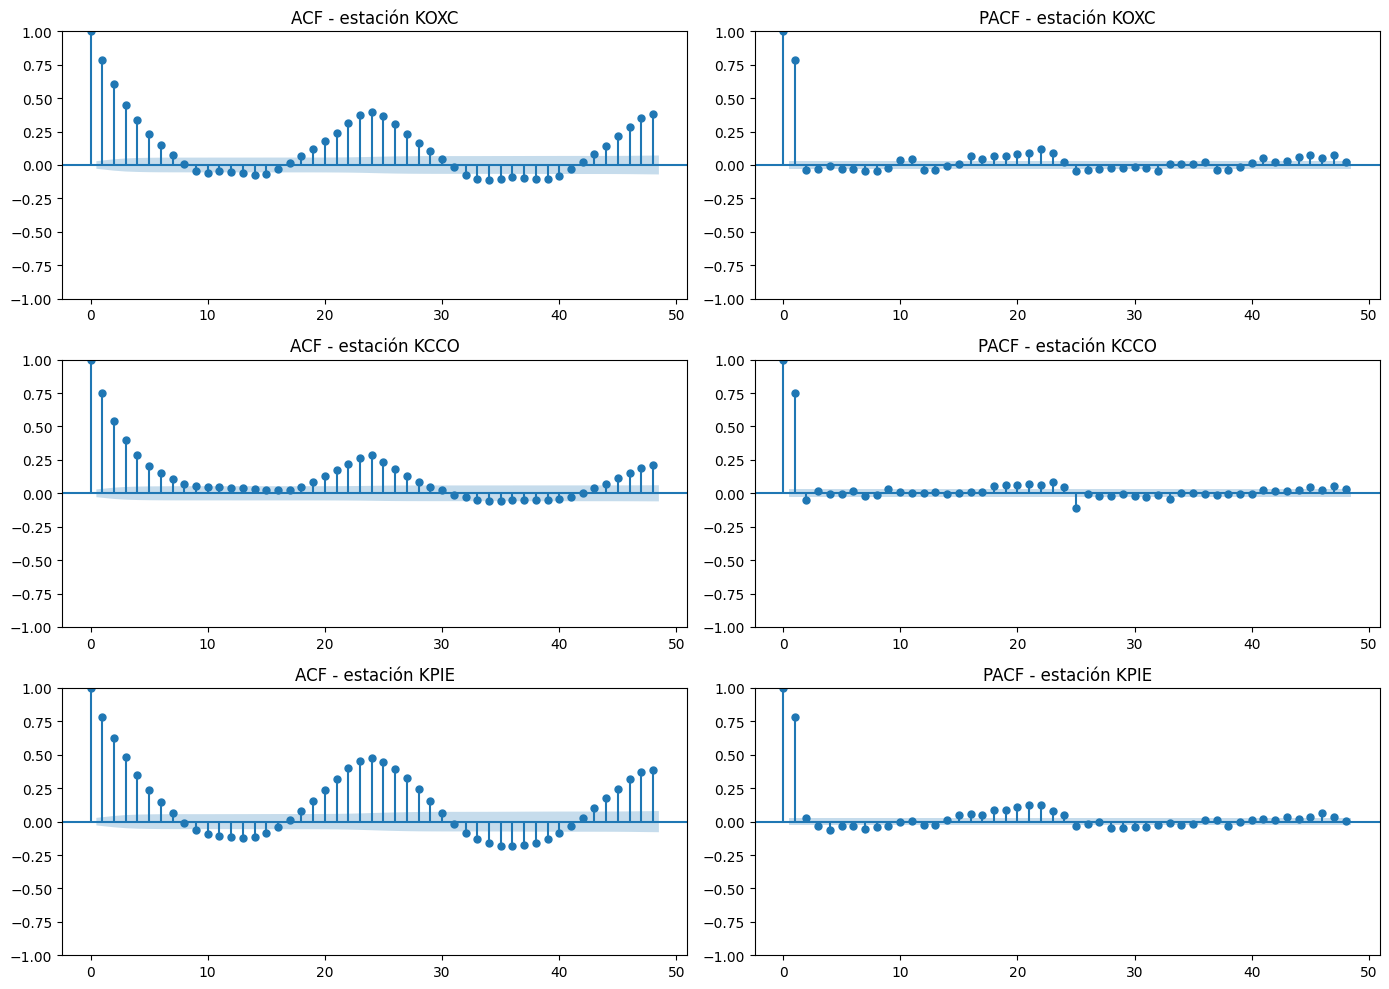

In [35]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Tomamos 3 estaciones al azar para no graficar 500
estaciones_muestra = df_modelo["station_id"].drop_duplicates().sample(3, random_state=42).tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, est in enumerate(estaciones_muestra):
    serie = (df_modelo[df_modelo["station_id"] == est]
             .sort_values("fecha_hora")["error_humedad"]
             .dropna())
    plot_acf(serie, lags=48, ax=axes[i, 0], title=f"ACF - estación {est}")
    plot_pacf(serie, lags=48, ax=axes[i, 1], title=f"PACF - estación {est}", method="ywm")

plt.tight_layout()
plt.show()

## Modelo 1 v3:Agregar media movil de error_humedad por estacion

In [36]:
# Rolling means SOBRE EL PASADO (shift(1) primero para no incluir t)
df_modelo["error_humedad_rollmean3"] = (
    df_modelo.groupby("station_id", observed=True)["error_humedad"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
)

df_modelo["error_humedad_rollmean6"] = (
    df_modelo.groupby("station_id", observed=True)["error_humedad"]
    .transform(lambda s: s.shift(1).rolling(window=6, min_periods=1).mean())
)

print(f"Nulos rollmean3: {df_modelo['error_humedad_rollmean3'].isna().sum():,}")
print(f"Nulos rollmean6: {df_modelo['error_humedad_rollmean6'].isna().sum():,}")

# Sanity check: ver que el rolling no incluye el valor actual
print("\nSanity check (primeras filas de una estación):")
est_check = df_modelo["station_id"].iloc[0]
print(df_modelo[df_modelo["station_id"] == est_check][
    ["fecha_hora","error_humedad","error_humedad_lag1","error_humedad_rollmean3"]
].head(6))

Nulos rollmean3: 500
Nulos rollmean6: 500

Sanity check (primeras filas de una estación):
           fecha_hora  error_humedad  error_humedad_lag1  \
0 2025-10-27 00:00:00          -10.0                 NaN   
1 2025-10-27 01:00:00           -9.0               -10.0   
2 2025-10-27 02:00:00            1.0                -9.0   
3 2025-10-27 03:00:00           -2.0                 1.0   
4 2025-10-27 04:00:00            0.0                -2.0   
5 2025-10-27 05:00:00            3.0                 0.0   

   error_humedad_rollmean3  
0                      NaN  
1               -10.000000  
2                -9.500000  
3                -6.000000  
4                -3.333333  
5                -0.333333  


Depurar features

In [37]:
features = [
    "station_id",
    "obs_temperature_celsius",
    "obs_wind_speed_ms",
    "obs_precipitation_last_hour_m",
    # cíclicas (las únicas temporales que sirvieron)
    "hora_sin",
    "hora_cos",
    "dia_anio",
    "mes_cos",
    # lags
    "error_humedad_lag1",
    "error_humedad_lag24",
    # nuevos: rolling means
    "error_humedad_rollmean3",
    "error_humedad_rollmean6",
]
cat_features = ["station_id"]
target = "error_humedad"

X_train = df_modelo.loc[mask_train, features].copy()
y_train = df_modelo.loc[mask_train, target]
X_test  = df_modelo.loc[mask_test,  features].copy()
y_test  = df_modelo.loc[mask_test,  target]

X_train["station_id"] = X_train["station_id"].astype(str)
X_test["station_id"]  = X_test["station_id"].astype(str)

print(f"Features finales ({len(features)}): {features}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Features finales (12): ['station_id', 'obs_temperature_celsius', 'obs_wind_speed_ms', 'obs_precipitation_last_hour_m', 'hora_sin', 'hora_cos', 'dia_anio', 'mes_cos', 'error_humedad_lag1', 'error_humedad_lag24', 'error_humedad_rollmean3', 'error_humedad_rollmean6']
X_train: (1875000, 12), X_test: (468676, 12)


Reentreno Catboost v3

In [38]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

modelo_cat_v3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)
modelo_cat_v3.fit(train_pool, eval_set=test_pool)

0:	learn: 6.6518917	test: 6.6774933	best: 6.6774933 (0)	total: 855ms	remaining: 14m 13s
100:	learn: 3.6318883	test: 4.5973856	best: 4.5924626 (59)	total: 1m 5s	remaining: 9m 44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4.592462606
bestIteration = 59

Shrink model to first 60 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='MAE', random_seed=42, verbose=100)

Comparar todo y rehacer features importance

In [39]:
y_pred_v3 = modelo_cat_v3.predict(X_test)
rmse_v3 = np.sqrt(mean_squared_error(y_test, y_pred_v3))
mae_v3  = mean_absolute_error(y_test, y_pred_v3)

print(f"{'Modelo':<45} {'RMSE':>10} {'MAE':>10}")
print("-" * 67)
print(f"{'Benchmark':<45} {rmse_bench:>10.4f} {mae_bench:>10.4f}")
print(f"{'CatBoost v1 (base)':<45} {14.4226:>10.4f} {'-':>10}")
print(f"{'CatBoost v2 (+ temporales + lags)':<45} {rmse_cat:>10.4f} {mae_cat:>10.4f}")
print(f"{'CatBoost v3 (+ rolling, sin features muertas)':<45} {rmse_v3:>10.4f} {mae_v3:>10.4f}")
print("-" * 67)
print(f"{'Mejora v3 vs benchmark - RMSE':<45} {(1 - rmse_v3/rmse_bench)*100:>9.2f}%")
print(f"{'Mejora v3 vs benchmark - MAE':<45} {(1 - mae_v3/mae_bench)*100:>9.2f}%")

print("\n📊 Feature importance v3:")
imp_v3 = pd.DataFrame({
    "feature": features,
    "importance": modelo_cat_v3.feature_importances_
}).sort_values("importance", ascending=False)
print(imp_v3.to_string(index=False))

Modelo                                              RMSE        MAE
-------------------------------------------------------------------
Benchmark                                         9.3241     7.1109
CatBoost v1 (base)                               14.4226          -
CatBoost v2 (+ temporales + lags)                 6.4187     4.5906
CatBoost v3 (+ rolling, sin features muertas)     6.4265     4.5925
-------------------------------------------------------------------
Mejora v3 vs benchmark - RMSE                     31.08%
Mejora v3 vs benchmark - MAE                      35.42%

📊 Feature importance v3:
                      feature  importance
           error_humedad_lag1   81.021296
                     hora_cos    6.731897
                     hora_sin    5.330835
          error_humedad_lag24    2.997149
      obs_temperature_celsius    1.296246
obs_precipitation_last_hour_m    0.896435
                   station_id    0.542794
            obs_wind_speed_ms    0.498461
      

observacion: los rolling means quedaron en 0% de importancia

## Modelos con Fold

Funcion que corre un fold

In [40]:
from dateutil.relativedelta import relativedelta

def correr_fold(df, fecha_inicio_train, fecha_fin_train, fecha_fin_test,
                features, cat_features, target, fold_id):
    """
    Entrena benchmark + CatBoost en un fold y devuelve métricas.
    """
    # Máscaras del fold
    mask_tr = (df["fecha_hora"] >= fecha_inicio_train) & (df["fecha_hora"] <= fecha_fin_train)
    mask_te = (df["fecha_hora"] >  fecha_fin_train)   & (df["fecha_hora"] <= fecha_fin_test)

    if mask_tr.sum() == 0 or mask_te.sum() == 0:
        return None

    y_tr = df.loc[mask_tr, target]
    y_te = df.loc[mask_te, target]

    # --- Benchmark recalculado en este fold ---
    prom = (df.loc[mask_tr]
              .groupby(["station_id", "Hora"], observed=True)[target]
              .mean()
              .rename("pred_bench")
              .reset_index())
    df_te_bench = df.loc[mask_te, ["station_id", "Hora"]].merge(prom, on=["station_id","Hora"], how="left")
    # Fallback con promedio global por si aparece alguna combinación nueva
    df_te_bench["pred_bench"] = df_te_bench["pred_bench"].fillna(y_tr.mean())
    rmse_b = np.sqrt(mean_squared_error(y_te, df_te_bench["pred_bench"]))
    mae_b  = mean_absolute_error(y_te, df_te_bench["pred_bench"])

    # --- CatBoost ---
    X_tr = df.loc[mask_tr, features].copy()
    X_te = df.loc[mask_te, features].copy()
    X_tr["station_id"] = X_tr["station_id"].astype(str)
    X_te["station_id"] = X_te["station_id"].astype(str)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    test_pool  = Pool(X_te, y_te, cat_features=cat_features)

    modelo = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        loss_function="MAE",
        eval_metric="MAE",
        random_seed=42,
        early_stopping_rounds=100,
        verbose=0,  # silencioso dentro del loop
    )
    modelo.fit(train_pool, eval_set=test_pool)

    y_pred = modelo.predict(X_te)
    rmse_c = np.sqrt(mean_squared_error(y_te, y_pred))
    mae_c  = mean_absolute_error(y_te, y_pred)

    return {
        "fold": fold_id,
        "train_inicio": fecha_inicio_train,
        "train_fin": fecha_fin_train,
        "test_fin": fecha_fin_test,
        "n_train": int(mask_tr.sum()),
        "n_test": int(mask_te.sum()),
        "std_train": float(y_tr.std()),
        "std_test": float(y_te.std()),
        "rmse_bench": rmse_b,
        "mae_bench": mae_b,
        "rmse_cat": rmse_c,
        "mae_cat": mae_c,
        "best_iter": modelo.get_best_iteration(),
    }

Armar ventanas y correr el loop

In [41]:
# Definir las ventanas: train = 3 meses, test = 1 mes, paso = 1 mes
fecha_min = df_modelo["fecha_hora"].min().normalize()
fecha_max = df_modelo["fecha_hora"].max().normalize()
print(f"Rango total: {fecha_min} → {fecha_max}")

folds_config = []
fold_id = 1
inicio_train = fecha_min

while True:
    fin_train = inicio_train + relativedelta(months=3)
    fin_test  = fin_train + relativedelta(months=1)
    if fin_train >= fecha_max:
        break
    folds_config.append((fold_id, inicio_train, fin_train, min(fin_test, fecha_max)))
    inicio_train = inicio_train + relativedelta(months=1)
    fold_id += 1

print(f"\nFolds a correr: {len(folds_config)}")
for f in folds_config:
    print(f"  Fold {f[0]}: train [{f[1].date()} → {f[2].date()}]  test [{f[2].date()} → {f[3].date()}]")

Rango total: 2025-10-27 00:00:00 → 2026-05-30 00:00:00

Folds a correr: 5
  Fold 1: train [2025-10-27 → 2026-01-27]  test [2026-01-27 → 2026-02-27]
  Fold 2: train [2025-11-27 → 2026-02-27]  test [2026-02-27 → 2026-03-27]
  Fold 3: train [2025-12-27 → 2026-03-27]  test [2026-03-27 → 2026-04-27]
  Fold 4: train [2026-01-27 → 2026-04-27]  test [2026-04-27 → 2026-05-27]
  Fold 5: train [2026-02-27 → 2026-05-27]  test [2026-05-27 → 2026-05-30]


Correr loop sobre 4 folds

In [42]:
import time

resultados = []
t_inicio = time.time()

for fold_id, ini_tr, fin_tr, fin_te in folds_config:
    print(f"\n🔄 Fold {fold_id}: train [{ini_tr.date()} → {fin_tr.date()}]  test [{fin_tr.date()} → {fin_te.date()}]")
    t0 = time.time()
    res = correr_fold(
        df=df_modelo,
        fecha_inicio_train=ini_tr,
        fecha_fin_train=fin_tr,
        fecha_fin_test=fin_te,
        features=features,
        cat_features=cat_features,
        target=target,
        fold_id=fold_id,
    )
    if res is not None:
        resultados.append(res)
        print(f"   ✓ n_train={res['n_train']:,} | n_test={res['n_test']:,}")
        print(f"   std_train={res['std_train']:.2f} | std_test={res['std_test']:.2f}")
        print(f"   Benchmark -> RMSE: {res['rmse_bench']:.4f} | MAE: {res['mae_bench']:.4f}")
        print(f"   CatBoost  -> RMSE: {res['rmse_cat']:.4f}  | MAE: {res['mae_cat']:.4f}  | best_iter: {res['best_iter']}")
        print(f"   ⏱ {time.time()-t0:.1f}s")

print(f"\n✅ Total: {(time.time()-t_inicio)/60:.1f} min")


🔄 Fold 1: train [2025-10-27 → 2026-01-27]  test [2026-01-27 → 2026-02-27]
   ✓ n_train=1,104,500 | n_test=372,000
   std_train=8.70 | std_test=10.78
   Benchmark -> RMSE: 9.9176 | MAE: 7.6093
   CatBoost  -> RMSE: 5.1636  | MAE: 3.8354  | best_iter: 540
   ⏱ 217.8s

🔄 Fold 2: train [2025-11-27 → 2026-02-27]  test [2026-02-27 → 2026-03-27]
   ✓ n_train=1,104,500 | n_test=336,000
   std_train=9.60 | std_test=9.61
   Benchmark -> RMSE: 8.6169 | MAE: 6.5732
   CatBoost  -> RMSE: 5.1716  | MAE: 3.7605  | best_iter: 658
   ⏱ 241.5s

🔄 Fold 3: train [2025-12-27 → 2026-03-27]  test [2026-03-27 → 2026-04-27]
   ✓ n_train=1,080,500 | n_test=308,709
   std_train=9.84 | std_test=9.23
   Benchmark -> RMSE: 8.8558 | MAE: 6.7423
   CatBoost  -> RMSE: 5.5999  | MAE: 4.0122  | best_iter: 996
   ⏱ 307.1s

🔄 Fold 4: train [2026-01-27 → 2026-04-27]  test [2026-04-27 → 2026-05-27]
   ✓ n_train=1,017,209 | n_test=195,881
   std_train=10.05 | std_test=9.20
   Benchmark -> RMSE: 10.0244 | MAE: 7.7211
   CatB

Resumen consolidado de folds

In [43]:
res_df = pd.DataFrame(resultados)

# Tabla por fold
print("📋 Resultados por fold:\n")
cols_show = ["fold","n_train","n_test","std_train","std_test",
             "rmse_bench","rmse_cat","mae_bench","mae_cat","best_iter"]
print(res_df[cols_show].round(4).to_string(index=False))

# Promedios y desvíos
print("\n📊 Promedio (± desvío) entre folds:")
print(f"  Benchmark RMSE: {res_df['rmse_bench'].mean():.4f} ± {res_df['rmse_bench'].std():.4f}")
print(f"  CatBoost  RMSE: {res_df['rmse_cat'].mean():.4f} ± {res_df['rmse_cat'].std():.4f}")
print(f"  Benchmark MAE:  {res_df['mae_bench'].mean():.4f} ± {res_df['mae_bench'].std():.4f}")
print(f"  CatBoost  MAE:  {res_df['mae_cat'].mean():.4f} ± {res_df['mae_cat'].std():.4f}")

mejora_rmse = (1 - res_df['rmse_cat'].mean() / res_df['rmse_bench'].mean()) * 100
mejora_mae  = (1 - res_df['mae_cat'].mean()  / res_df['mae_bench'].mean())  * 100
print(f"\n  Mejora promedio CatBoost vs Benchmark:")
print(f"    RMSE: {mejora_rmse:.2f}%")
print(f"    MAE:  {mejora_mae:.2f}%")

📋 Resultados por fold:

 fold  n_train  n_test  std_train  std_test  rmse_bench  rmse_cat  mae_bench  mae_cat  best_iter
    1  1104500  372000     8.6979   10.7825      9.9176    5.1636     7.6093   3.8354        540
    2  1104500  336000     9.6029    9.6057      8.6169    5.1716     6.5732   3.7605        658
    3  1080500  308709     9.8408    9.2264      8.8558    5.5999     6.7423   4.0122        996
    4  1017209  195881    10.0548    9.2022     10.0244    6.7313     7.7211   4.8955        166
    5   841090   20884     9.3893    8.6836      8.9384    6.2249     6.8008   4.5457        713

📊 Promedio (± desvío) entre folds:
  Benchmark RMSE: 9.2706 ± 0.6512
  CatBoost  RMSE: 5.7783 ± 0.6866
  Benchmark MAE:  7.0894 ± 0.5338
  CatBoost  MAE:  4.2098 ± 0.4910

  Mejora promedio CatBoost vs Benchmark:
    RMSE: 37.67%
    MAE:  40.62%


Grafico de evolucion de folds

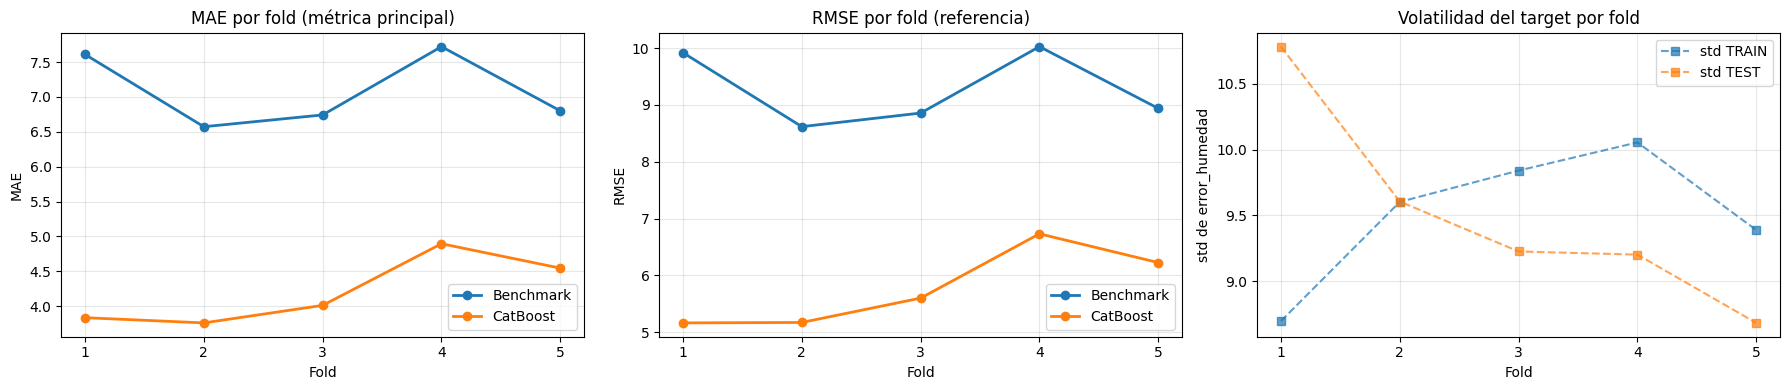

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(res_df["fold"], res_df["mae_bench"], "o-", label="Benchmark", linewidth=2)
axes[0].plot(res_df["fold"], res_df["mae_cat"],   "o-", label="CatBoost",  linewidth=2)
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("MAE")
axes[0].set_title("MAE por fold (métrica principal)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xticks(res_df["fold"])

axes[1].plot(res_df["fold"], res_df["rmse_bench"], "o-", label="Benchmark", linewidth=2)
axes[1].plot(res_df["fold"], res_df["rmse_cat"],   "o-", label="CatBoost",  linewidth=2)
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE por fold (referencia)"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(res_df["fold"])

axes[2].plot(res_df["fold"], res_df["std_train"], "s--", label="std TRAIN", alpha=0.7)
axes[2].plot(res_df["fold"], res_df["std_test"],  "s--", label="std TEST",  alpha=0.7)
axes[2].set_xlabel("Fold"); axes[2].set_ylabel("std de error_humedad")
axes[2].set_title("Volatilidad del target por fold"); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_xticks(res_df["fold"])

plt.tight_layout(); plt.show()


Observacion: El fold 3 entrena hasta 27-mar y testea hasta 27-abr. El fold 4 entrena INCLUYENDO ese mismo período crítico y se recupera. Eso sugiere que hay un evento o cambio de patrón a fines de marzo / principios de abril que el modelo no puede anticipar si no lo vio en entrenamiento.
Diagnostico fold 3:

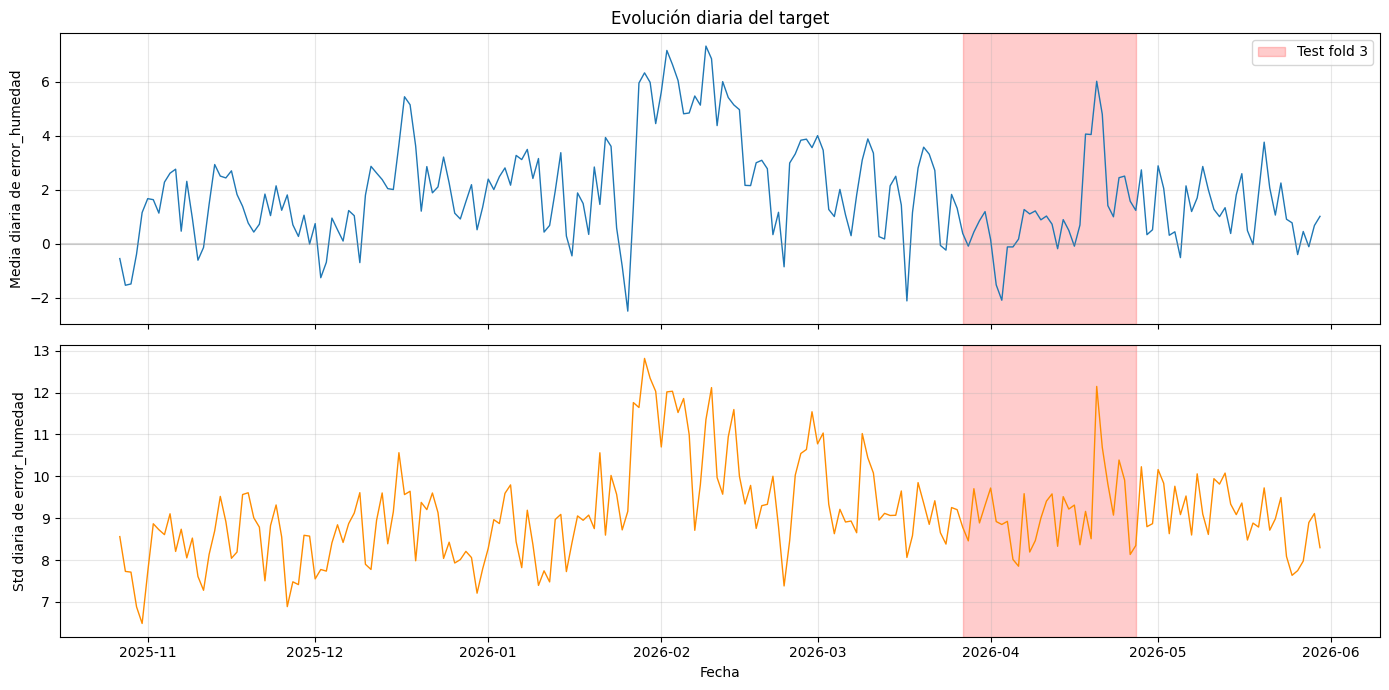


Resumen mensual:
           mean     std   count
mes_anio                       
2025-10  -0.555   7.573   60000
2025-11   1.413   8.514  360000
2025-12   1.767   8.772  372000
2026-01   2.275   9.634  372000
2026-02   4.184  10.517  336000
2026-03   1.578   9.416  372000
2026-04   0.884   9.258  273807
2026-05   1.287   9.134  197869


In [45]:
import matplotlib.pyplot as plt

# Serie diaria de media y std del error_humedad
diario = (df_modelo
    .set_index("fecha_hora")
    .groupby(pd.Grouper(freq="D"))["error_humedad"]
    .agg(["mean", "std", "count"])
    .reset_index())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(diario["fecha_hora"], diario["mean"], linewidth=1)
axes[0].axhline(0, color="grey", alpha=0.3)
axes[0].set_ylabel("Media diaria de error_humedad")
axes[0].set_title("Evolución diaria del target")
axes[0].axvspan(pd.Timestamp("2026-03-27"), pd.Timestamp("2026-04-27"),
                alpha=0.2, color="red", label="Test fold 3")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(diario["fecha_hora"], diario["std"], linewidth=1, color="darkorange")
axes[1].set_ylabel("Std diaria de error_humedad")
axes[1].set_xlabel("Fecha")
axes[1].axvspan(pd.Timestamp("2026-03-27"), pd.Timestamp("2026-04-27"),
                alpha=0.2, color="red")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Stats por mes
mensual = (df_modelo.assign(mes_anio=df_modelo["fecha_hora"].dt.to_period("M"))
                    .groupby("mes_anio")["error_humedad"]
                    .agg(["mean","std","count"])
                    .round(3))
print("\nResumen mensual:")
print(mensual)

# Construccion de fcst compensado

In [46]:
# Reconstruir el dataset de test con las columnas que necesitamos
df_eval = df.loc[
    df["fecha_hora"].isin(df_modelo.loc[mask_test, "fecha_hora"].unique()) &
    df["station_id"].isin(df_modelo.loc[mask_test, "station_id"].unique()),
    ["station_id", "fecha_hora", "Hora", "latitude", "longitude",
     "obs_relative_humidity_pct", "fcst_relative_humidity_pct"]
].copy()

# Mergear con las predicciones del modelo (sobre test)
preds = df_modelo.loc[mask_test, ["station_id","fecha_hora","error_humedad"]].copy()
preds["error_pred"] = y_pred_v3

df_eval = df_eval.merge(preds, on=["station_id","fecha_hora"], how="inner")

# fcst compensado = fcst original + error predicho
# (porque error = obs - fcst, entonces obs ≈ fcst + error)
df_eval["fcst_compensado"] = df_eval["fcst_relative_humidity_pct"] + df_eval["error_pred"]

# Recortar a rango físico [0, 100] (la humedad relativa no puede salirse de ahí)
df_eval["fcst_compensado"] = df_eval["fcst_compensado"].clip(0, 100)

# Errores residuales
df_eval["error_original"]    = df_eval["obs_relative_humidity_pct"] - df_eval["fcst_relative_humidity_pct"]
df_eval["error_compensado"]  = df_eval["obs_relative_humidity_pct"] - df_eval["fcst_compensado"]

print(f"Filas en df_eval: {len(df_eval):,}")
print(f"\nMétricas comparativas (sobre test):")
print(f"  MAE  original   : {df_eval['error_original'].abs().mean():.4f}")
print(f"  MAE  compensado : {df_eval['error_compensado'].abs().mean():.4f}")
print(f"  RMSE original   : {np.sqrt((df_eval['error_original']**2).mean()):.4f}")
print(f"  RMSE compensado : {np.sqrt((df_eval['error_compensado']**2).mean()):.4f}")
print(f"  Bias original   : {df_eval['error_original'].mean():.4f}")
print(f"  Bias compensado : {df_eval['error_compensado'].mean():.4f}")

Filas en df_eval: 468,676

Métricas comparativas (sobre test):
  MAE  original   : 6.9984
  MAE  compensado : 4.4972
  RMSE original   : 9.2682
  RMSE compensado : 6.3401
  Bias original   : 1.0324
  Bias compensado : 0.0411


## Error por Horario

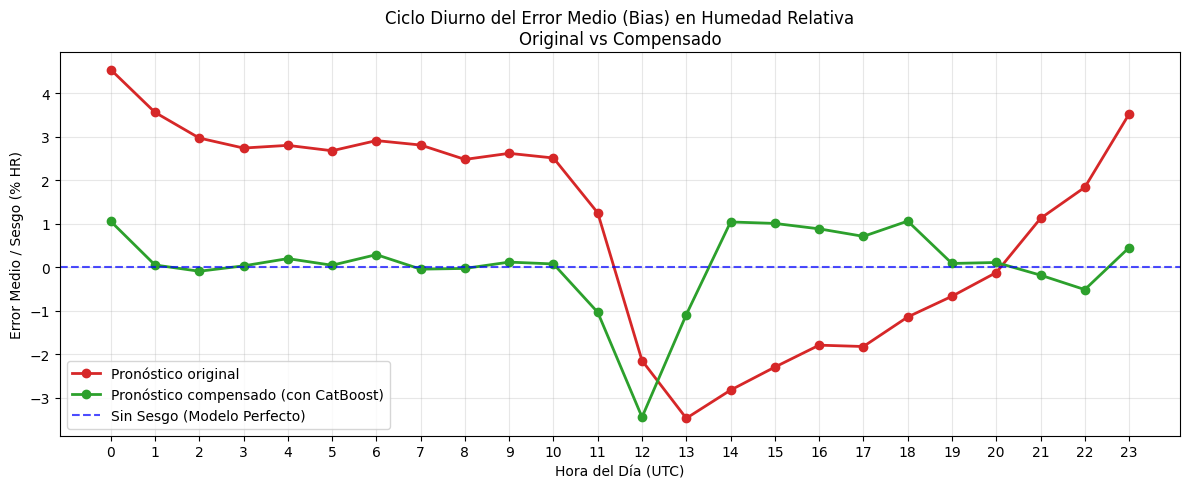

In [47]:
df_horarios_comp = df_eval.groupby("Hora").agg(
    error_orig=("error_original","mean"),
    error_comp=("error_compensado","mean"),
).reset_index()

plt.figure(figsize=(12,5))
plt.plot(df_horarios_comp["Hora"], df_horarios_comp["error_orig"],
         marker="o", linewidth=2, label="Pronóstico original", color="tab:red")
plt.plot(df_horarios_comp["Hora"], df_horarios_comp["error_comp"],
         marker="o", linewidth=2, label="Pronóstico compensado (con CatBoost)", color="tab:green")

plt.axhline(y=0, color="blue", linestyle="--", alpha=0.7, label="Sin Sesgo (Modelo Perfecto)")

plt.title("Ciclo Diurno del Error Medio (Bias) en Humedad Relativa\nOriginal vs Compensado")
plt.xlabel("Hora del Día (UTC)")
plt.ylabel("Error Medio / Sesgo (% HR)")
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

## Mapa de error promedio por estacion

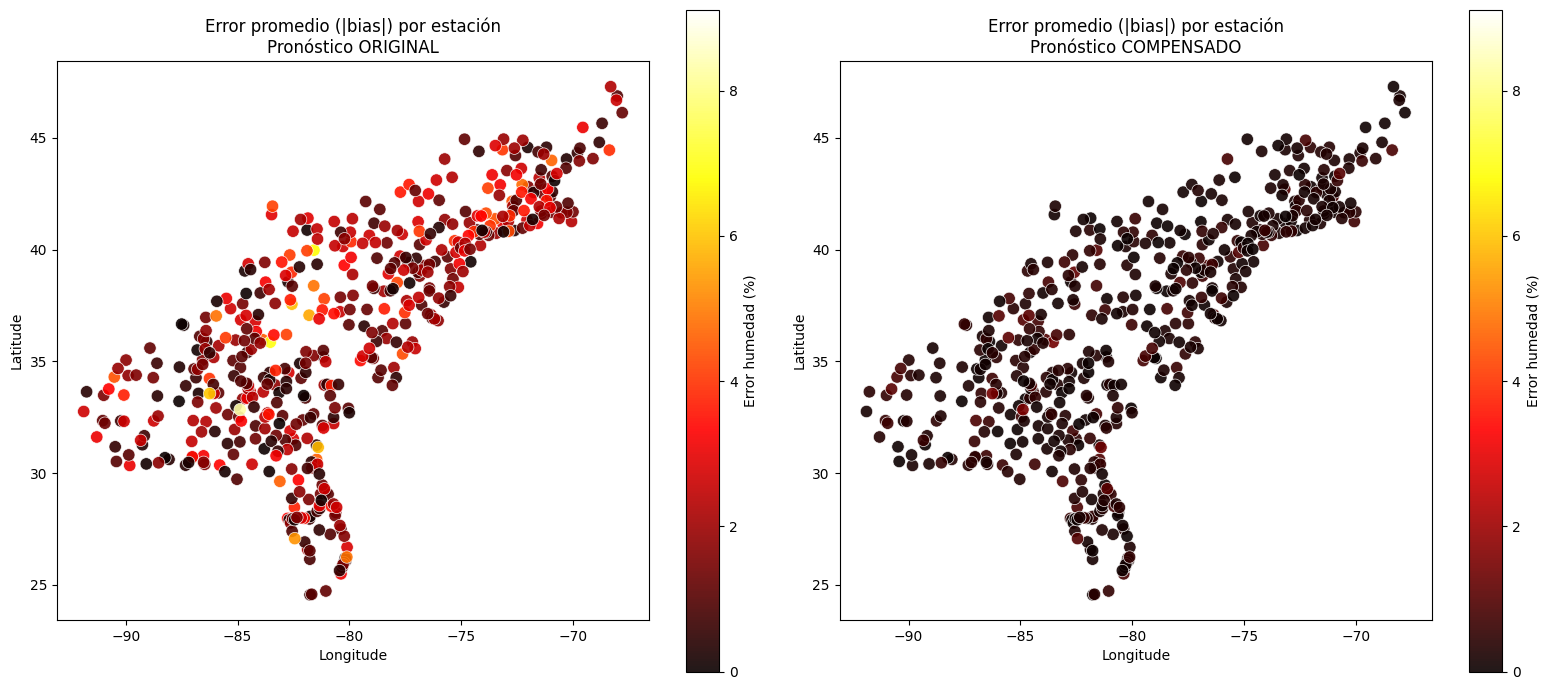

|Bias| promedio entre estaciones:
  Original   : 1.8768
  Compensado : 0.2993


In [48]:
df_est_comp = df_eval.groupby("station_id").agg(
    latitude=("latitude","mean"),
    longitude=("longitude","mean"),
    error_orig=("error_original","mean"),
    error_comp=("error_compensado","mean"),
).reset_index()

# Para que ambos mapas compartan la misma escala de color
vmax = max(df_est_comp["error_orig"].abs().max(),
           df_est_comp["error_comp"].abs().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, titulo in zip(
    axes,
    ["error_orig", "error_comp"],
    ["Pronóstico ORIGINAL", "Pronóstico COMPENSADO"]
):
    sc = ax.scatter(
        df_est_comp["longitude"], df_est_comp["latitude"],
        c=df_est_comp[col].abs(),
        cmap="hot", s=80, edgecolors="w", linewidths=0.5, alpha=0.9,
        vmin=0, vmax=vmax,
    )
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Error promedio (|bias|) por estación\n{titulo}")
    ax.set_aspect("equal", adjustable="box")
    plt.colorbar(sc, ax=ax, label="Error humedad (%)")

plt.tight_layout()
plt.show()

print(f"|Bias| promedio entre estaciones:")
print(f"  Original   : {df_est_comp['error_orig'].abs().mean():.4f}")
print(f"  Compensado : {df_est_comp['error_comp'].abs().mean():.4f}")

## Scatter plot obs vs fcst (original y compensado)

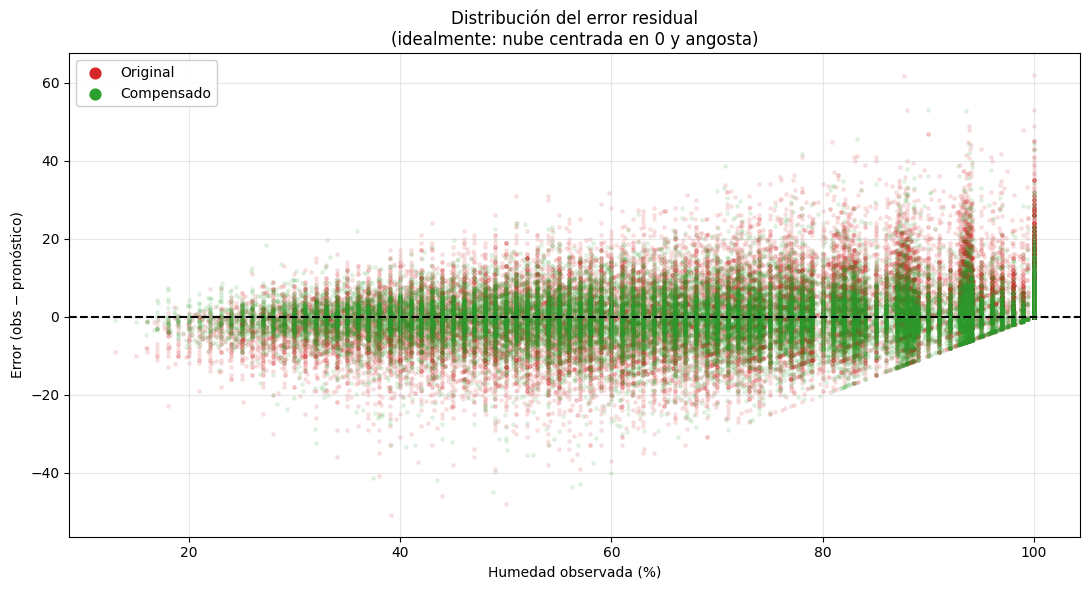

In [49]:
sample = df_eval.sample(min(30_000, len(df_eval)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))

err_o = sample["obs_relative_humidity_pct"] - sample["fcst_relative_humidity_pct"]
err_c = sample["obs_relative_humidity_pct"] - sample["fcst_compensado"]

ax.scatter(sample["obs_relative_humidity_pct"], err_o,
           alpha=0.10, s=6, color="tab:red", label="Original")
ax.scatter(sample["obs_relative_humidity_pct"], err_c,
           alpha=0.10, s=6, color="tab:green", label="Compensado")
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)

ax.set_xlabel("Humedad observada (%)")
ax.set_ylabel("Error (obs − pronóstico)")
ax.set_title("Distribución del error residual\n(idealmente: nube centrada en 0 y angosta)")
ax.grid(alpha=0.3)

leg = ax.legend(loc="upper left", framealpha=0.95)
for h in leg.legend_handles:
    h.set_alpha(1.0); h.set_sizes([60])

plt.tight_layout()
plt.show()

## Nuevo modelo: agrego fcst para predecir el error

In [50]:
# Tomar fcst único por (station_id, fecha_hora) para evitar explosión de filas
fcst_lookup = (df[["station_id","fecha_hora","fcst_relative_humidity_pct"]]
               .drop_duplicates(subset=["station_id","fecha_hora"], keep="first"))

# Guardar el tamaño antes
n_antes = len(df_modelo)

df_modelo = df_modelo.merge(
    fcst_lookup,
    on=["station_id","fecha_hora"],
    how="left"
)

# Verificar que no creció el df
print(f"Filas antes del merge: {n_antes:,}")
print(f"Filas después:         {len(df_modelo):,}")
assert len(df_modelo) == n_antes, "⚠️ El merge cambió el tamaño del df. Hay duplicados en df."

# Recalcular las máscaras (por las dudas, baratísimo)
mask_train = df_modelo["fecha_hora"] <= fecha_corte
mask_test  = df_modelo["fecha_hora"] >  fecha_corte

print(f"\nNulos en fcst_relative_humidity_pct: {df_modelo['fcst_relative_humidity_pct'].isna().sum():,}")
print(df_modelo[["fecha_hora","error_humedad","fcst_relative_humidity_pct"]].head())

Filas antes del merge: 2,343,676
Filas después:         2,343,676

Nulos en fcst_relative_humidity_pct: 0
           fecha_hora  error_humedad  fcst_relative_humidity_pct
0 2025-10-27 00:00:00          -10.0                        83.0
1 2025-10-27 01:00:00           -9.0                        86.0
2 2025-10-27 02:00:00            1.0                        81.0
3 2025-10-27 03:00:00           -2.0                        86.0
4 2025-10-27 04:00:00            0.0                        87.0


Reentrenar v5

In [51]:
features_v5 = [
    "station_id",
    "obs_temperature_celsius",
    "obs_wind_speed_ms",
    "obs_precipitation_last_hour_m",
    "hora_sin",
    "hora_cos",
    "dia_anio",
    "mes_cos",
    "error_humedad_lag1",
    "error_humedad_lag24",
    "error_humedad_rollmean3",
    "error_humedad_rollmean6",
    "fcst_relative_humidity_pct",   # 👈 nueva
]
cat_features = ["station_id"]

X_train = df_modelo.loc[mask_train, features_v5].copy()
y_train = df_modelo.loc[mask_train, target]
X_test  = df_modelo.loc[mask_test,  features_v5].copy()
y_test  = df_modelo.loc[mask_test,  target]

X_train["station_id"] = X_train["station_id"].astype(str)
X_test["station_id"]  = X_test["station_id"].astype(str)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

modelo_cat_v5 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)
modelo_cat_v5.fit(train_pool, eval_set=test_pool)

0:	learn: 6.6644586	test: 6.7137642	best: 6.7137642 (0)	total: 536ms	remaining: 8m 55s
100:	learn: 3.4317979	test: 4.4359674	best: 4.4349807 (98)	total: 57.4s	remaining: 8m 30s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4.433685305
bestIteration = 122

Shrink model to first 123 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='MAE', random_seed=42, verbose=100)

Comparar v3 vs v5 + importancias

In [52]:
y_pred_v5 = modelo_cat_v5.predict(X_test)
rmse_v5 = np.sqrt(mean_squared_error(y_test, y_pred_v5))
mae_v5  = mean_absolute_error(y_test, y_pred_v5)

print(f"{'Modelo':<45} {'RMSE':>10} {'MAE':>10}")
print("-" * 67)
print(f"{'Benchmark':<45} {rmse_bench:>10.4f} {mae_bench:>10.4f}")
print(f"{'CatBoost v3 (sin fcst)':<45} {rmse_v3:>10.4f} {mae_v3:>10.4f}")
print(f"{'CatBoost v5 (con fcst)':<45} {rmse_v5:>10.4f} {mae_v5:>10.4f}")
print("-" * 67)
print(f"{'Mejora v5 vs v3 - MAE':<45} {(1 - mae_v5/mae_v3)*100:>9.2f}%")

print(f"\n📊 Feature importance v5:")
imp_v5 = pd.DataFrame({
    "feature": features_v5,
    "importance": modelo_cat_v5.feature_importances_
}).sort_values("importance", ascending=False)
print(imp_v5.to_string(index=False))

print(f"\nIteración donde frenó: {modelo_cat_v5.get_best_iteration()}")

Modelo                                              RMSE        MAE
-------------------------------------------------------------------
Benchmark                                         9.3241     7.1109
CatBoost v3 (sin fcst)                            6.4265     4.5925
CatBoost v5 (con fcst)                            6.1835     4.4337
-------------------------------------------------------------------
Mejora v5 vs v3 - MAE                              3.46%

📊 Feature importance v5:
                      feature  importance
           error_humedad_lag1   68.298157
   fcst_relative_humidity_pct   11.637108
                     hora_sin    5.592865
                     hora_cos    3.892247
          error_humedad_lag24    2.883515
obs_precipitation_last_hour_m    2.636878
      obs_temperature_celsius    2.107738
            obs_wind_speed_ms    1.156838
                   station_id    0.575967
                     dia_anio    0.541936
      error_humedad_rollmean6    0.271822
     

Rehago ultimo scatter

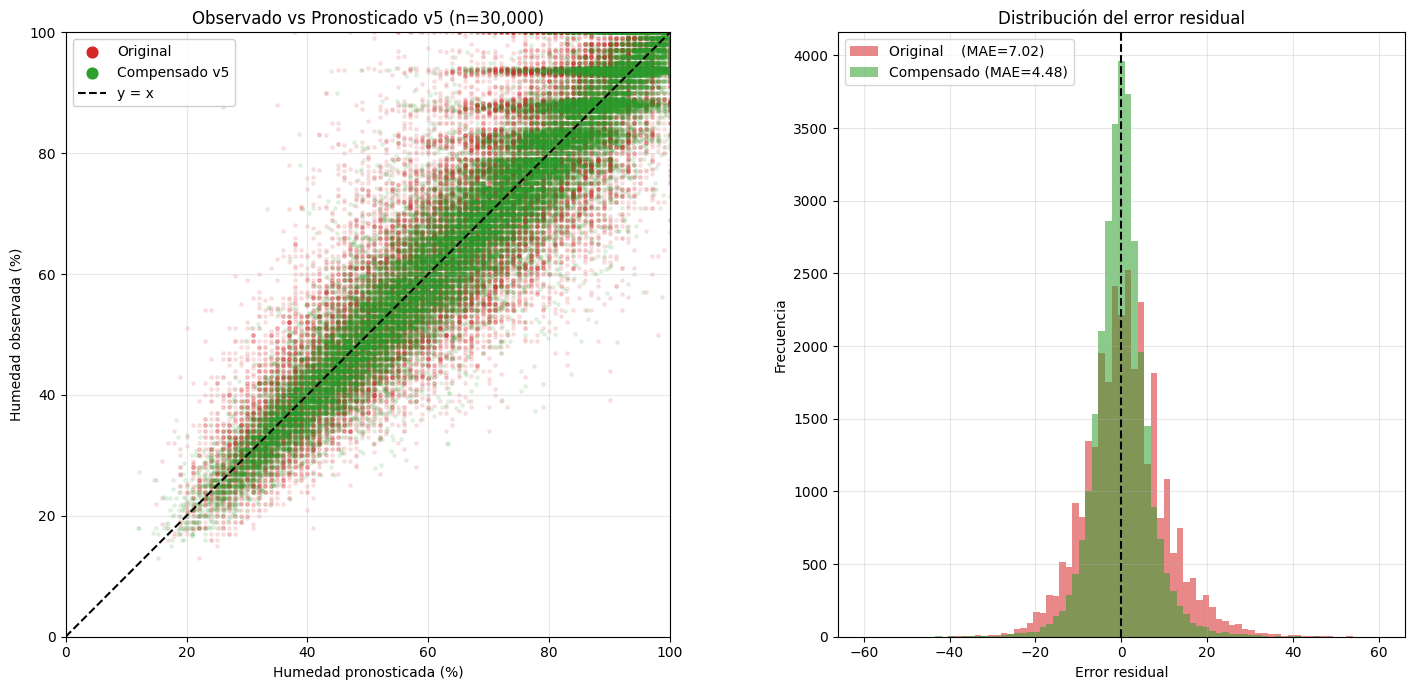

In [53]:
# Reconstruir df_eval con las predicciones del v5
preds_v5 = df_modelo.loc[mask_test, ["station_id","fecha_hora"]].copy()
preds_v5["error_pred"] = y_pred_v5

df_eval_v5 = df_eval[["station_id","fecha_hora","Hora","latitude","longitude",
                       "obs_relative_humidity_pct","fcst_relative_humidity_pct","error_humedad"]].merge(
    preds_v5, on=["station_id","fecha_hora"], how="inner"
)
df_eval_v5["fcst_compensado"] = (df_eval_v5["fcst_relative_humidity_pct"] +
                                   df_eval_v5["error_pred"]).clip(0, 100)

# Mismo gráfico C pero comparando v3 vs v5
sample = df_eval_v5.sample(min(30_000, len(df_eval_v5)), random_state=42)
err_o = sample["obs_relative_humidity_pct"] - sample["fcst_relative_humidity_pct"]
err_c = sample["obs_relative_humidity_pct"] - sample["fcst_compensado"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios":[1.5, 1]})

ax = axes[0]
ax.scatter(sample["fcst_relative_humidity_pct"], sample["obs_relative_humidity_pct"],
           alpha=0.10, s=6, color="tab:red", label="Original")
ax.scatter(sample["fcst_compensado"], sample["obs_relative_humidity_pct"],
           alpha=0.10, s=6, color="tab:green", label="Compensado v5")
ax.plot([0,100],[0,100], color="black", linestyle="--", linewidth=1.5, label="y = x")
ax.set_xlabel("Humedad pronosticada (%)"); ax.set_ylabel("Humedad observada (%)")
ax.set_title(f"Observado vs Pronosticado v5 (n={len(sample):,})")
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect("equal"); ax.grid(alpha=0.3)
leg = ax.legend(loc="upper left", framealpha=0.95)
for h in leg.legend_handles[:2]:
    h.set_alpha(1.0); h.set_sizes([60])

ax = axes[1]
bins = np.linspace(-60, 60, 80)
ax.hist(err_o, bins=bins, alpha=0.55, color="tab:red",   label=f"Original    (MAE={err_o.abs().mean():.2f})")
ax.hist(err_c, bins=bins, alpha=0.55, color="tab:green", label=f"Compensado (MAE={err_c.abs().mean():.2f})")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Error residual"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del error residual"); ax.legend(loc="upper left"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

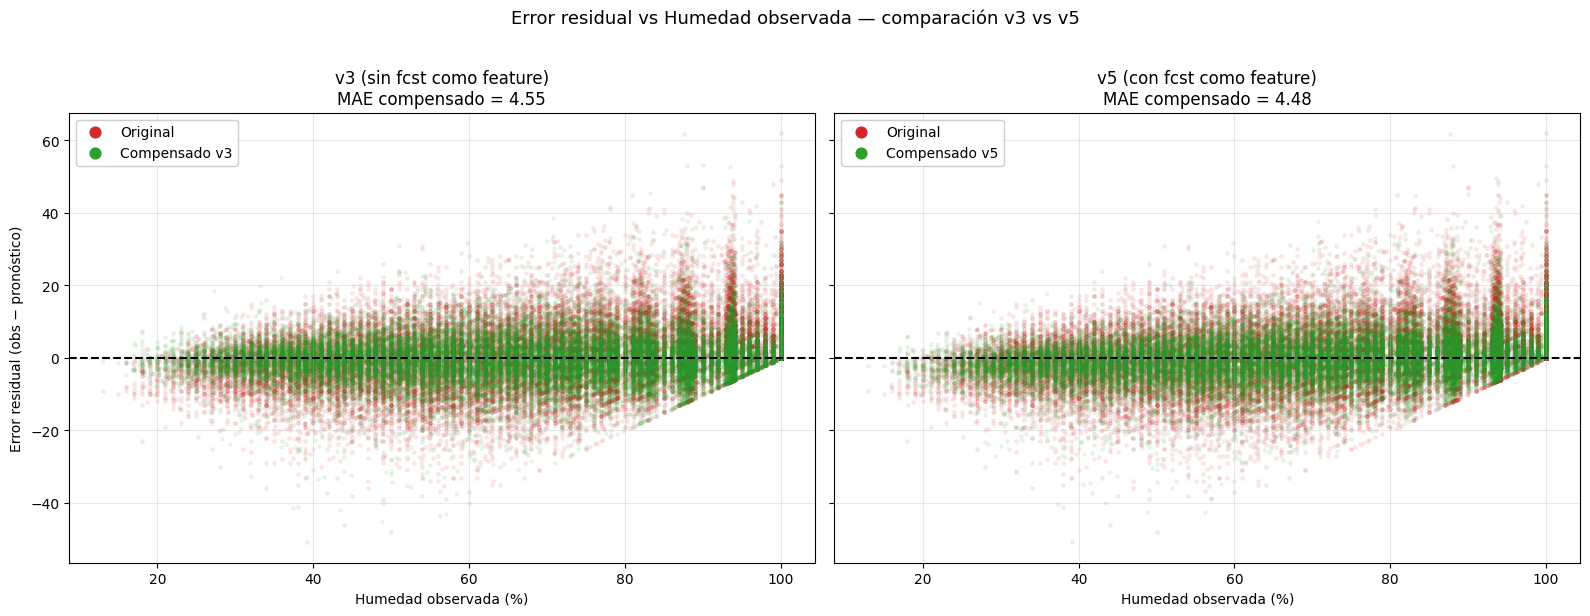

In [54]:
# Reusamos df_eval_v5 que armaste en la celda anterior, agregando también v3
df_eval_v5["err_orig"]  = df_eval_v5["obs_relative_humidity_pct"] - df_eval_v5["fcst_relative_humidity_pct"]
df_eval_v5["err_v5"]    = df_eval_v5["obs_relative_humidity_pct"] - df_eval_v5["fcst_compensado"]

# Para incluir v3 en la comparación
df_eval["err_orig"]   = df_eval["obs_relative_humidity_pct"] - df_eval["fcst_relative_humidity_pct"]
df_eval["err_v3"]     = df_eval["obs_relative_humidity_pct"] - df_eval["fcst_compensado"]  # éste es v3 (calculado antes)

sample_v5 = df_eval_v5.sample(min(30_000, len(df_eval_v5)), random_state=42)
sample_v3 = df_eval.sample(min(30_000, len(df_eval)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# v3
ax = axes[0]
ax.scatter(sample_v3["obs_relative_humidity_pct"], sample_v3["err_orig"],
           alpha=0.08, s=6, color="tab:red",   label="Original")
ax.scatter(sample_v3["obs_relative_humidity_pct"], sample_v3["err_v3"],
           alpha=0.08, s=6, color="tab:green", label="Compensado v3")
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Humedad observada (%)"); ax.set_ylabel("Error residual (obs − pronóstico)")
ax.set_title(f"v3 (sin fcst como feature)\nMAE compensado = {sample_v3['err_v3'].abs().mean():.2f}")
ax.grid(alpha=0.3)
leg = ax.legend(loc="upper left", framealpha=0.95)
for h in leg.legend_handles: h.set_alpha(1.0); h.set_sizes([60])

# v5
ax = axes[1]
ax.scatter(sample_v5["obs_relative_humidity_pct"], sample_v5["err_orig"],
           alpha=0.08, s=6, color="tab:red",   label="Original")
ax.scatter(sample_v5["obs_relative_humidity_pct"], sample_v5["err_v5"],
           alpha=0.08, s=6, color="tab:green", label="Compensado v5")
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Humedad observada (%)")
ax.set_title(f"v5 (con fcst como feature)\nMAE compensado = {sample_v5['err_v5'].abs().mean():.2f}")
ax.grid(alpha=0.3)
leg = ax.legend(loc="upper left", framealpha=0.95)
for h in leg.legend_handles: h.set_alpha(1.0); h.set_sizes([60])

plt.suptitle("Error residual vs Humedad observada — comparación v3 vs v5", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Folds para v5

In [55]:
def correr_fold_v5(df, fecha_inicio_train, fecha_fin_train, fecha_fin_test,
                   features, cat_features, target, fold_id):
    """
    Entrena benchmark + CatBoost en un fold. Devuelve métricas en dos espacios:
      - error_humedad (target del modelo)
      - humedad final compensada (métrica de negocio)
    """
    mask_tr = (df["fecha_hora"] >= fecha_inicio_train) & (df["fecha_hora"] <= fecha_fin_train)
    mask_te = (df["fecha_hora"] >  fecha_fin_train)   & (df["fecha_hora"] <= fecha_fin_test)

    if mask_tr.sum() == 0 or mask_te.sum() == 0:
        return None

    y_tr = df.loc[mask_tr, target]
    y_te = df.loc[mask_te, target]

    # --- Benchmark (recalculado) ---
    prom = (df.loc[mask_tr]
              .groupby(["station_id", "Hora"], observed=True)[target]
              .mean().rename("pred_bench").reset_index())
    df_te_bench = df.loc[mask_te, ["station_id", "Hora"]].merge(prom, on=["station_id","Hora"], how="left")
    df_te_bench["pred_bench"] = df_te_bench["pred_bench"].fillna(y_tr.mean())
    rmse_b = np.sqrt(mean_squared_error(y_te, df_te_bench["pred_bench"]))
    mae_b  = mean_absolute_error(y_te, df_te_bench["pred_bench"])

    # --- CatBoost ---
    X_tr = df.loc[mask_tr, features].copy()
    X_te = df.loc[mask_te, features].copy()
    X_tr["station_id"] = X_tr["station_id"].astype(str)
    X_te["station_id"] = X_te["station_id"].astype(str)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    test_pool  = Pool(X_te, y_te, cat_features=cat_features)

    modelo = CatBoostRegressor(
        iterations=1000, learning_rate=0.1, depth=6,
        loss_function="MAE", eval_metric="MAE",
        random_seed=42, early_stopping_rounds=100, verbose=0,
    )
    modelo.fit(train_pool, eval_set=test_pool)

    y_pred = modelo.predict(X_te)
    rmse_c = np.sqrt(mean_squared_error(y_te, y_pred))
    mae_c  = mean_absolute_error(y_te, y_pred)

    # --- Métricas en ESPACIO DE HUMEDAD ---
    fcst_te = df.loc[mask_te, "fcst_relative_humidity_pct"]
    obs_te  = df.loc[mask_te, "fcst_relative_humidity_pct"] + y_te  # obs = fcst + error_real

    fcst_compensado = (fcst_te + y_pred).clip(0, 100)

    mae_hum_orig = (obs_te - fcst_te).abs().mean()
    mae_hum_comp = (obs_te - fcst_compensado).abs().mean()
    mejora_hum   = (1 - mae_hum_comp / mae_hum_orig) * 100

    return {
        "fold": fold_id,
        "train_inicio": fecha_inicio_train,
        "train_fin": fecha_fin_train,
        "test_fin": fecha_fin_test,
        "n_train": int(mask_tr.sum()),
        "n_test": int(mask_te.sum()),
        "std_train": float(y_tr.std()),
        "std_test": float(y_te.std()),
        # métricas en espacio de error_humedad
        "rmse_bench": rmse_b,
        "mae_bench": mae_b,
        "rmse_cat": rmse_c,
        "mae_cat": mae_c,
        # métricas en espacio de humedad final (negocio)
        "mae_hum_orig": mae_hum_orig,
        "mae_hum_comp": mae_hum_comp,
        "mejora_hum_pct": mejora_hum,
        "best_iter": modelo.get_best_iteration(),
    }

Correr loop

In [56]:
# Verificación rápida
assert "fcst_relative_humidity_pct" in df_modelo.columns, "Falta fcst_relative_humidity_pct"

# Features v5
features_v5 = [
    "station_id",
    "obs_temperature_celsius",
    "obs_wind_speed_ms",
    "obs_precipitation_last_hour_m",
    "hora_sin",
    "hora_cos",
    "dia_anio",
    "mes_cos",
    "error_humedad_lag1",
    "error_humedad_lag24",
    "error_humedad_rollmean3",
    "error_humedad_rollmean6",
    "fcst_relative_humidity_pct",
]
cat_features = ["station_id"]

import time
resultados_v5 = []
t_inicio = time.time()

for fold_id, ini_tr, fin_tr, fin_te in folds_config:
    print(f"\n🔄 Fold {fold_id}: train [{ini_tr.date()} → {fin_tr.date()}]  test [{fin_tr.date()} → {fin_te.date()}]")
    t0 = time.time()
    res = correr_fold_v5(
        df=df_modelo,
        fecha_inicio_train=ini_tr,
        fecha_fin_train=fin_tr,
        fecha_fin_test=fin_te,
        features=features_v5,
        cat_features=cat_features,
        target=target,
        fold_id=fold_id,
    )
    if res is not None:
        resultados_v5.append(res)
        print(f"   ✓ n_train={res['n_train']:,} | n_test={res['n_test']:,}")
        print(f"   [error]    Bench MAE: {res['mae_bench']:.4f} | Cat MAE: {res['mae_cat']:.4f}  | best_iter: {res['best_iter']}")
        print(f"   [humedad]  Orig MAE:  {res['mae_hum_orig']:.4f} | Comp MAE: {res['mae_hum_comp']:.4f} | Mejora: {res['mejora_hum_pct']:.2f}%")
        print(f"   ⏱ {time.time()-t0:.1f}s")

print(f"\n✅ Total: {(time.time()-t_inicio)/60:.1f} min")


🔄 Fold 1: train [2025-10-27 → 2026-01-27]  test [2026-01-27 → 2026-02-27]
   ✓ n_train=1,104,500 | n_test=372,000
   [error]    Bench MAE: 7.6093 | Cat MAE: 3.5087  | best_iter: 605
   [humedad]  Orig MAE:  8.9217 | Comp MAE: 3.5087 | Mejora: 60.67%
   ⏱ 239.6s

🔄 Fold 2: train [2025-11-27 → 2026-02-27]  test [2026-02-27 → 2026-03-27]
   ✓ n_train=1,104,500 | n_test=336,000
   [error]    Bench MAE: 6.5732 | Cat MAE: 3.4682  | best_iter: 441
   [humedad]  Orig MAE:  7.4271 | Comp MAE: 3.4682 | Mejora: 53.30%
   ⏱ 174.8s

🔄 Fold 3: train [2025-12-27 → 2026-03-27]  test [2026-03-27 → 2026-04-27]
   ✓ n_train=1,080,500 | n_test=308,709
   [error]    Bench MAE: 6.7423 | Cat MAE: 3.8501  | best_iter: 399
   [humedad]  Orig MAE:  7.0275 | Comp MAE: 3.8500 | Mejora: 45.22%
   ⏱ 156.4s

🔄 Fold 4: train [2026-01-27 → 2026-04-27]  test [2026-04-27 → 2026-05-27]
   ✓ n_train=1,017,209 | n_test=195,881
   [error]    Bench MAE: 7.7211 | Cat MAE: 4.8411  | best_iter: 170
   [humedad]  Orig MAE:  6.9

Resumen Consolidado

In [57]:
res_v5_df = pd.DataFrame(resultados_v5)

print("📋 Resultados por fold (v5):\n")
cols = ["fold","n_test","std_test","mae_bench","mae_cat",
        "mae_hum_orig","mae_hum_comp","mejora_hum_pct","best_iter"]
print(res_v5_df[cols].round(3).to_string(index=False))

print("\n📊 Promedio (± desvío) entre folds:")
print(f"\n  Espacio error_humedad:")
print(f"    Benchmark MAE: {res_v5_df['mae_bench'].mean():.4f} ± {res_v5_df['mae_bench'].std():.4f}")
print(f"    CatBoost  MAE: {res_v5_df['mae_cat'].mean():.4f} ± {res_v5_df['mae_cat'].std():.4f}")
print(f"    Mejora: {(1 - res_v5_df['mae_cat'].mean()/res_v5_df['mae_bench'].mean())*100:.2f}%")

print(f"\n  Espacio humedad observada (métrica de negocio):")
print(f"    Pronóstico ORIGINAL    MAE: {res_v5_df['mae_hum_orig'].mean():.4f} ± {res_v5_df['mae_hum_orig'].std():.4f}")
print(f"    Pronóstico COMPENSADO  MAE: {res_v5_df['mae_hum_comp'].mean():.4f} ± {res_v5_df['mae_hum_comp'].std():.4f}")
print(f"    🎯 Mejora promedio:    {res_v5_df['mejora_hum_pct'].mean():.2f}% ± {res_v5_df['mejora_hum_pct'].std():.2f}%")

📋 Resultados por fold (v5):

 fold  n_test  std_test  mae_bench  mae_cat  mae_hum_orig  mae_hum_comp  mejora_hum_pct  best_iter
    1  372000    10.782      7.609    3.509         8.922         3.509          60.672        605
    2  336000     9.606      6.573    3.468         7.427         3.468          53.304        441
    3  308709     9.226      6.742    3.850         7.028         3.850          45.215        399
    4  195881     9.202      7.721    4.841         6.994         4.836          30.845        170
    5   20884     8.684      6.801    4.112         6.641         4.100          38.255        992

📊 Promedio (± desvío) entre folds:

  Espacio error_humedad:
    Benchmark MAE: 7.0894 ± 0.5338
    CatBoost  MAE: 3.9560 ± 0.5606
    Mejora: 44.20%

  Espacio humedad observada (métrica de negocio):
    Pronóstico ORIGINAL    MAE: 7.4021 ± 0.8940
    Pronóstico COMPENSADO  MAE: 3.9527 ± 0.5580
    🎯 Mejora promedio:    45.66% ± 11.81%


Gráfico evolucion

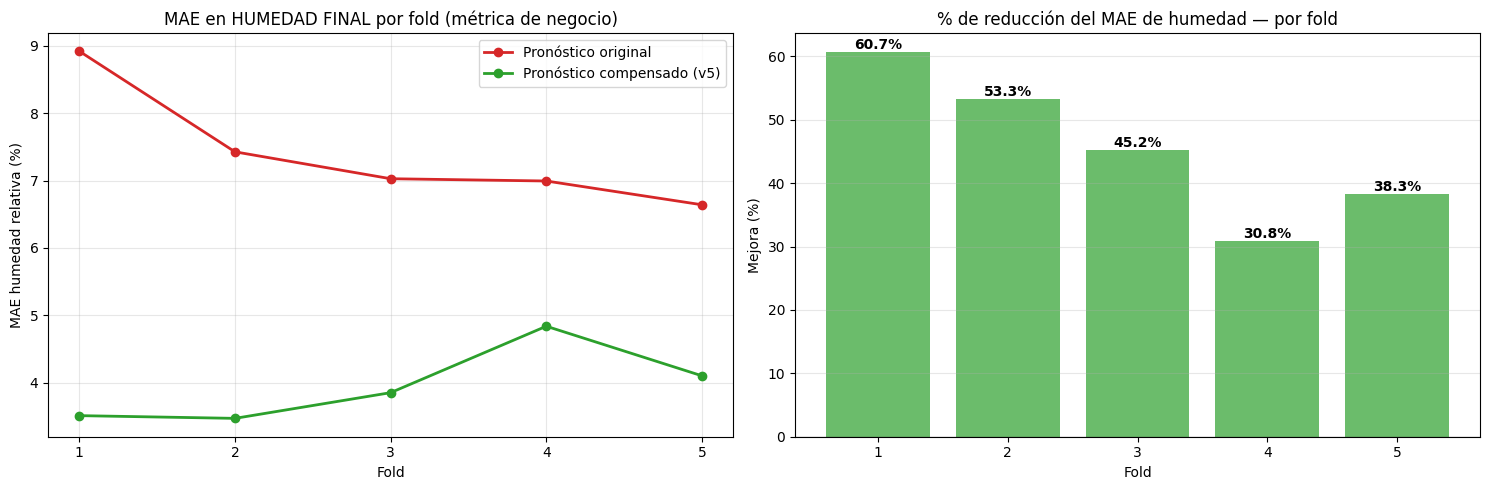

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE en espacio de humedad (métrica de negocio)
axes[0].plot(res_v5_df["fold"], res_v5_df["mae_hum_orig"], "o-", color="tab:red",
             label="Pronóstico original", linewidth=2)
axes[0].plot(res_v5_df["fold"], res_v5_df["mae_hum_comp"], "o-", color="tab:green",
             label="Pronóstico compensado (v5)", linewidth=2)
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("MAE humedad relativa (%)")
axes[0].set_title("MAE en HUMEDAD FINAL por fold (métrica de negocio)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xticks(res_v5_df["fold"])

# % de mejora por fold
axes[1].bar(res_v5_df["fold"], res_v5_df["mejora_hum_pct"], color="tab:green", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Mejora (%)")
axes[1].set_title("% de reducción del MAE de humedad — por fold")
axes[1].grid(alpha=0.3, axis="y")
axes[1].set_xticks(res_v5_df["fold"])
for i, v in enumerate(res_v5_df["mejora_hum_pct"]):
    axes[1].text(res_v5_df["fold"].iloc[i], v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Optimizacion Ventanas

In [59]:
def evaluar_tamano_ventana(df, meses_train, meses_test, paso_meses,
                            features, cat_features, target, verbose=False):
    """
    Corre walk-forward con un tamaño de train dado y devuelve MAE promedio entre folds.
    """
    fecha_min = df["fecha_hora"].min().normalize()
    fecha_max = df["fecha_hora"].max().normalize()

    # Generar folds
    folds = []
    fold_id = 1
    inicio = fecha_min
    while True:
        fin_tr = inicio + relativedelta(months=meses_train)
        fin_te = fin_tr + relativedelta(months=meses_test)
        if fin_tr >= fecha_max:
            break
        folds.append((fold_id, inicio, fin_tr, min(fin_te, fecha_max)))
        inicio = inicio + relativedelta(months=paso_meses)
        fold_id += 1

    if not folds:
        return None

    # Correr todos los folds
    resultados = []
    t0 = time.time()
    for fid, ini_tr, fin_tr, fin_te in folds:
        res = correr_fold_v5(df, ini_tr, fin_tr, fin_te,
                              features, cat_features, target, fid)
        if res is not None:
            resultados.append(res)
            if verbose:
                print(f"  Fold {fid}: MAE_error={res['mae_cat']:.3f}  MAE_hum={res['mae_hum_comp']:.3f}")
    duracion = time.time() - t0

    res_df = pd.DataFrame(resultados)
    return {
        "meses_train": meses_train,
        "n_folds": len(resultados),
        "mae_error_mean": res_df["mae_cat"].mean(),
        "mae_error_std":  res_df["mae_cat"].std(),
        "mae_hum_mean":   res_df["mae_hum_comp"].mean(),
        "mae_hum_std":    res_df["mae_hum_comp"].std(),
        "mejora_hum_mean": res_df["mejora_hum_pct"].mean(),
        "best_iter_mean": res_df["best_iter"].mean(),
        "n_train_mean":   res_df["n_train"].mean(),
        "duracion_seg":   duracion,
    }


# Probar diferentes tamaños de ventana
tamanos = [1, 2, 3]  # meses de train
comparacion = []

for m in tamanos:
    print(f"\n🔄 Probando ventana de {m} mes(es) de train...")
    res = evaluar_tamano_ventana(
        df=df_modelo,
        meses_train=m,
        meses_test=1,
        paso_meses=1,
        features=features_v5,
        cat_features=cat_features,
        target=target,
        verbose=True,
    )
    if res is not None:
        comparacion.append(res)
        print(f"   → {res['n_folds']} folds | MAE_hum={res['mae_hum_mean']:.3f} ± {res['mae_hum_std']:.3f} | ⏱ {res['duracion_seg']:.0f}s")

comp_df = pd.DataFrame(comparacion)
print("\n" + "="*70)
print("📊 Comparación de tamaños de ventana:")
print("="*70)
print(comp_df.round(3).to_string(index=False))


🔄 Probando ventana de 1 mes(es) de train...
  Fold 1: MAE_error=3.431  MAE_hum=3.430
  Fold 2: MAE_error=3.383  MAE_hum=3.383
  Fold 3: MAE_error=3.503  MAE_hum=3.503
  Fold 4: MAE_error=3.580  MAE_hum=3.580
  Fold 5: MAE_error=3.814  MAE_hum=3.814
  Fold 6: MAE_error=4.810  MAE_hum=4.801
  Fold 7: MAE_error=4.161  MAE_hum=4.135
   → 7 folds | MAE_hum=3.807 ± 0.510 | ⏱ 356s

🔄 Probando ventana de 2 mes(es) de train...
  Fold 1: MAE_error=3.383  MAE_hum=3.382
  Fold 2: MAE_error=3.458  MAE_hum=3.458
  Fold 3: MAE_error=3.500  MAE_hum=3.500
  Fold 4: MAE_error=3.825  MAE_hum=3.825
  Fold 5: MAE_error=4.800  MAE_hum=4.795
  Fold 6: MAE_error=4.105  MAE_hum=4.089
   → 6 folds | MAE_hum=3.841 ± 0.538 | ⏱ 732s

🔄 Probando ventana de 3 mes(es) de train...
  Fold 1: MAE_error=3.509  MAE_hum=3.509
  Fold 2: MAE_error=3.468  MAE_hum=3.468
  Fold 3: MAE_error=3.850  MAE_hum=3.850
  Fold 4: MAE_error=4.841  MAE_hum=4.836
  Fold 5: MAE_error=4.112  MAE_hum=4.100
   → 5 folds | MAE_hum=3.953 ± 0.55

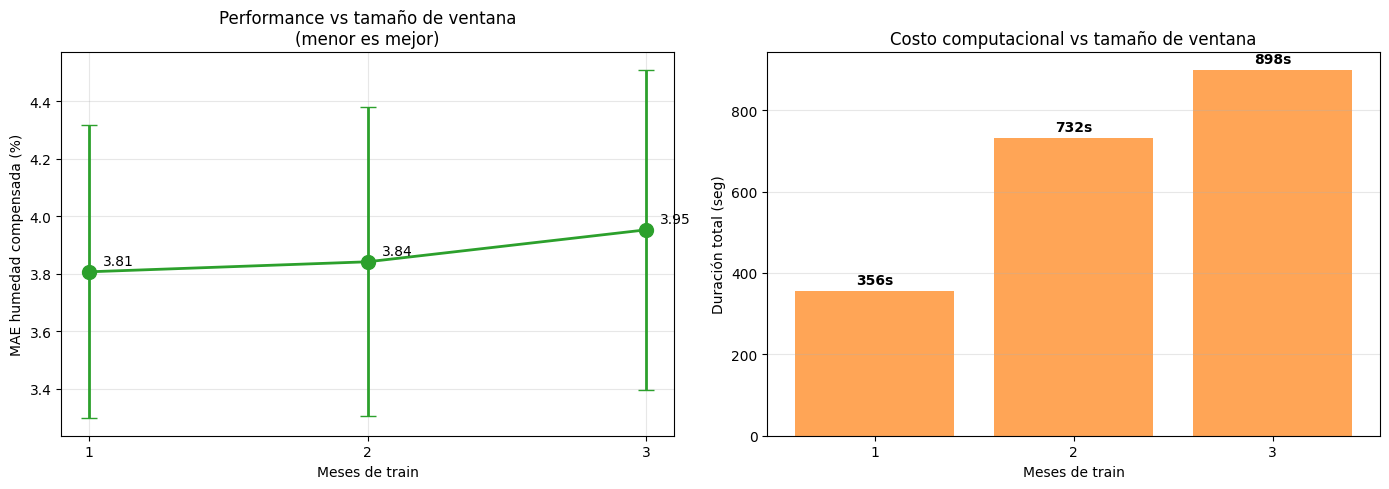

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE de humedad final vs tamaño de ventana
axes[0].errorbar(comp_df["meses_train"], comp_df["mae_hum_mean"],
                 yerr=comp_df["mae_hum_std"], marker="o", linewidth=2,
                 markersize=10, capsize=6, color="tab:green")
axes[0].set_xlabel("Meses de train")
axes[0].set_ylabel("MAE humedad compensada (%)")
axes[0].set_title("Performance vs tamaño de ventana\n(menor es mejor)")
axes[0].grid(alpha=0.3)
axes[0].set_xticks(comp_df["meses_train"])
for _, row in comp_df.iterrows():
    axes[0].annotate(f"{row['mae_hum_mean']:.2f}",
                     (row['meses_train'], row['mae_hum_mean']),
                     textcoords="offset points", xytext=(10, 5), fontsize=10)

# Tiempo de entrenamiento vs tamaño
axes[1].bar(comp_df["meses_train"], comp_df["duracion_seg"], color="tab:orange", alpha=0.7)
axes[1].set_xlabel("Meses de train")
axes[1].set_ylabel("Duración total (seg)")
axes[1].set_title("Costo computacional vs tamaño de ventana")
axes[1].grid(alpha=0.3, axis="y")
axes[1].set_xticks(comp_df["meses_train"])
for _, row in comp_df.iterrows():
    axes[1].annotate(f"{row['duracion_seg']:.0f}s",
                     (row['meses_train'], row['duracion_seg']),
                     ha="center", textcoords="offset points", xytext=(0, 5),
                     fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [61]:
from datetime import timedelta

def evaluar_tamano_ventana_dias(df, dias_train, dias_test, dias_paso,
                                  features, cat_features, target, verbose=False):
    """
    Walk-forward parametrizado en días (en lugar de meses).
    """
    fecha_min = df["fecha_hora"].min().normalize()
    fecha_max = df["fecha_hora"].max().normalize()

    folds = []
    fold_id = 1
    inicio = fecha_min
    while True:
        fin_tr = inicio + timedelta(days=dias_train)
        fin_te = fin_tr + timedelta(days=dias_test)
        if fin_tr >= fecha_max:
            break
        folds.append((fold_id, inicio, fin_tr, min(fin_te, fecha_max)))
        inicio = inicio + timedelta(days=dias_paso)
        fold_id += 1

    if not folds:
        return None

    resultados = []
    t0 = time.time()
    for fid, ini_tr, fin_tr, fin_te in folds:
        res = correr_fold_v5(df, ini_tr, fin_tr, fin_te,
                              features, cat_features, target, fid)
        if res is not None:
            resultados.append(res)
            if verbose:
                print(f"  Fold {fid}: MAE_hum={res['mae_hum_comp']:.3f}  best_iter={res['best_iter']}")
    duracion = time.time() - t0

    res_df = pd.DataFrame(resultados)
    return {
        "dias_train": dias_train,
        "dias_test":  dias_test,
        "n_folds":    len(resultados),
        "mae_error_mean": res_df["mae_cat"].mean(),
        "mae_error_std":  res_df["mae_cat"].std(),
        "mae_hum_mean":   res_df["mae_hum_comp"].mean(),
        "mae_hum_std":    res_df["mae_hum_comp"].std(),
        "mejora_hum_mean": res_df["mejora_hum_pct"].mean(),
        "best_iter_mean": res_df["best_iter"].mean(),
        "n_train_mean":   res_df["n_train"].mean(),
        "duracion_seg":   duracion,
    }


# Test fijo en 14 días para comparación justa, paso=14
configs = [
    (7,  14),
    (14, 14),
    (30, 14),   # ← el "1 mes" pero con test de 14d, para comparar manzanas con manzanas
]

comparacion_dias = []
for d_tr, d_te in configs:
    print(f"\n🔄 Probando train={d_tr}d / test={d_te}d...")
    res = evaluar_tamano_ventana_dias(
        df=df_modelo,
        dias_train=d_tr,
        dias_test=d_te,
        dias_paso=d_te,   # paso = duración del test (no se solapan)
        features=features_v5,
        cat_features=cat_features,
        target=target,
        verbose=True,
    )
    if res is not None:
        comparacion_dias.append(res)
        print(f"   → {res['n_folds']} folds | MAE_hum={res['mae_hum_mean']:.3f} ± {res['mae_hum_std']:.3f} | ⏱ {res['duracion_seg']:.0f}s")

comp_dias_df = pd.DataFrame(comparacion_dias)
print("\n" + "="*70)
print("📊 Comparación de tamaños de ventana (en días):")
print("="*70)
print(comp_dias_df.round(3).to_string(index=False))


🔄 Probando train=7d / test=14d...
  Fold 1: MAE_hum=3.579  best_iter=88
  Fold 2: MAE_hum=3.444  best_iter=88
  Fold 3: MAE_hum=3.186  best_iter=119
  Fold 4: MAE_hum=3.642  best_iter=99
  Fold 5: MAE_hum=3.411  best_iter=50
  Fold 6: MAE_hum=3.738  best_iter=86
  Fold 7: MAE_hum=4.124  best_iter=99
  Fold 8: MAE_hum=3.885  best_iter=45
  Fold 9: MAE_hum=3.438  best_iter=165
  Fold 10: MAE_hum=4.069  best_iter=27
  Fold 11: MAE_hum=3.524  best_iter=81
  Fold 12: MAE_hum=3.930  best_iter=36
  Fold 13: MAE_hum=5.226  best_iter=108
  Fold 14: MAE_hum=4.810  best_iter=129
  Fold 15: MAE_hum=4.363  best_iter=192
   → 15 folds | MAE_hum=3.891 ± 0.560 | ⏱ 235s

🔄 Probando train=14d / test=14d...
  Fold 1: MAE_hum=3.471  best_iter=113
  Fold 2: MAE_hum=3.226  best_iter=63
  Fold 3: MAE_hum=3.667  best_iter=54
  Fold 4: MAE_hum=3.334  best_iter=117
  Fold 5: MAE_hum=3.370  best_iter=150
  Fold 6: MAE_hum=3.627  best_iter=267
  Fold 7: MAE_hum=3.828  best_iter=66
  Fold 8: MAE_hum=3.452  best_i

2026-06-05 22:00:27,099 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-05 22:00:27,110 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-05 22:00:27,286 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-05 22:00:27,287 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-05 22:00:27,289 | INFO | Using categorical units to plot a list of strings that are all parsable as 

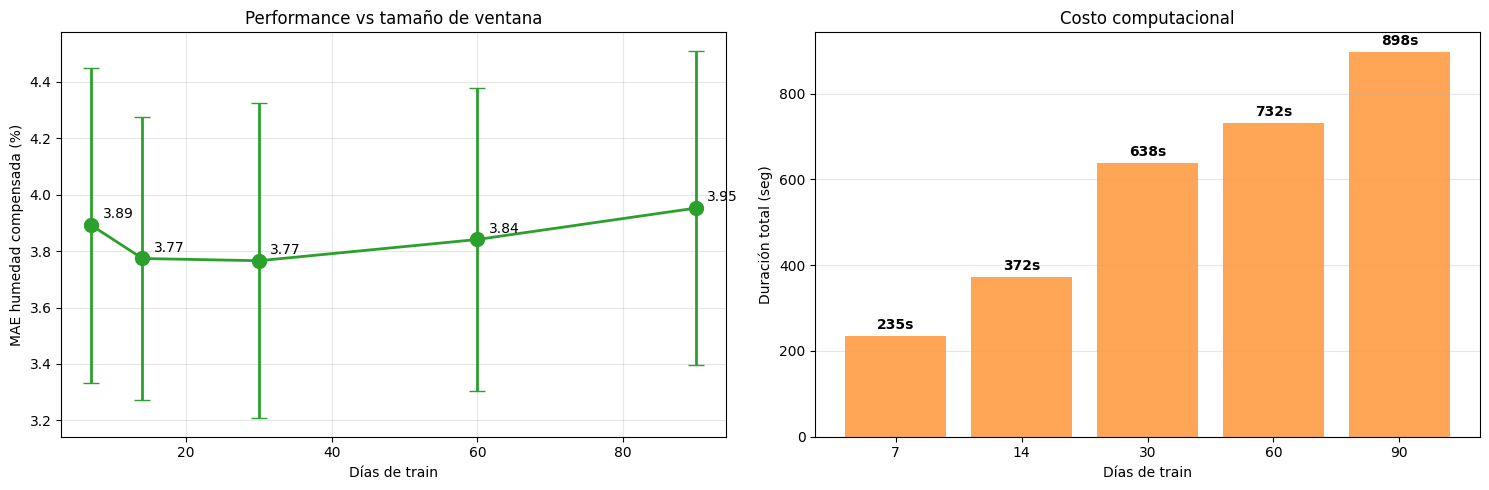

In [62]:
# Unificar las dos comparaciones (la tuya en meses + la nueva en días)
# Convertimos meses a días aprox para poner todo en un solo eje
comp_unificado = pd.DataFrame([
    {"dias_train": 7,   "mae": comp_dias_df.iloc[0]["mae_hum_mean"], "std": comp_dias_df.iloc[0]["mae_hum_std"], "tiempo": comp_dias_df.iloc[0]["duracion_seg"], "n_folds": comp_dias_df.iloc[0]["n_folds"]},
    {"dias_train": 14,  "mae": comp_dias_df.iloc[1]["mae_hum_mean"], "std": comp_dias_df.iloc[1]["mae_hum_std"], "tiempo": comp_dias_df.iloc[1]["duracion_seg"], "n_folds": comp_dias_df.iloc[1]["n_folds"]},
    {"dias_train": 30,  "mae": comp_dias_df.iloc[2]["mae_hum_mean"], "std": comp_dias_df.iloc[2]["mae_hum_std"], "tiempo": comp_dias_df.iloc[2]["duracion_seg"], "n_folds": comp_dias_df.iloc[2]["n_folds"]},
    {"dias_train": 60,  "mae": comp_df.iloc[1]["mae_hum_mean"],      "std": comp_df.iloc[1]["mae_hum_std"],      "tiempo": comp_df.iloc[1]["duracion_seg"],      "n_folds": comp_df.iloc[1]["n_folds"]},
    {"dias_train": 90,  "mae": comp_df.iloc[2]["mae_hum_mean"],      "std": comp_df.iloc[2]["mae_hum_std"],      "tiempo": comp_df.iloc[2]["duracion_seg"],      "n_folds": comp_df.iloc[2]["n_folds"]},
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(comp_unificado["dias_train"], comp_unificado["mae"],
                 yerr=comp_unificado["std"], marker="o", linewidth=2,
                 markersize=10, capsize=6, color="tab:green")
axes[0].set_xlabel("Días de train")
axes[0].set_ylabel("MAE humedad compensada (%)")
axes[0].set_title("Performance vs tamaño de ventana")
axes[0].grid(alpha=0.3)
for _, row in comp_unificado.iterrows():
    axes[0].annotate(f"{row['mae']:.2f}", (row['dias_train'], row['mae']),
                     textcoords="offset points", xytext=(8, 5), fontsize=10)

axes[1].bar(comp_unificado["dias_train"].astype(str), comp_unificado["tiempo"],
            color="tab:orange", alpha=0.7)
axes[1].set_xlabel("Días de train")
axes[1].set_ylabel("Duración total (seg)")
axes[1].set_title("Costo computacional")
axes[1].grid(alpha=0.3, axis="y")
for i, row in comp_unificado.iterrows():
    axes[1].annotate(f"{row['tiempo']:.0f}s",
                     (str(int(row['dias_train'])), row['tiempo']),
                     ha="center", textcoords="offset points", xytext=(0, 5),
                     fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# Optimizacion Hiperparámetros

In [63]:
# Si no tenés optuna: !pip install optuna
import subprocess
import sys

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna
from datetime import timedelta

# Generar los 15 folds (igual que la celda de ventanas)
fecha_min = df_modelo["fecha_hora"].min().normalize()
fecha_max = df_modelo["fecha_hora"].max().normalize()

folds_14d = []
fold_id = 1
inicio = fecha_min
while True:
    fin_tr = inicio + timedelta(days=14)
    fin_te = fin_tr + timedelta(days=14)
    if fin_tr >= fecha_max:
        break
    folds_14d.append((fold_id, inicio, fin_tr, min(fin_te, fecha_max)))
    inicio = inicio + timedelta(days=14)
    fold_id += 1

print(f"Folds totales con ventana 14d: {len(folds_14d)}")

# Elegir 3 folds representativos: uno temprano, uno medio, uno tardío
# (saltamos el primero porque no tiene historia previa para lags, y el último porque es chico)
idx_folds_hpo = [3, 8, 13]   # ajustar si querés
folds_hpo = [folds_14d[i] for i in idx_folds_hpo]

print(f"\nFolds elegidos para HPO:")
for f in folds_hpo:
    print(f"  Fold {f[0]}: train [{f[1].date()} → {f[2].date()}]  test [{f[2].date()} → {f[3].date()}]")

Folds totales con ventana 14d: 15

Folds elegidos para HPO:
  Fold 4: train [2025-12-08 → 2025-12-22]  test [2025-12-22 → 2026-01-05]
  Fold 9: train [2026-02-16 → 2026-03-02]  test [2026-03-02 → 2026-03-16]
  Fold 14: train [2026-04-27 → 2026-05-11]  test [2026-05-11 → 2026-05-25]


In [64]:
# Pre-armar los pools de cada fold HPO (esto ahorra horas en total)
pools_hpo = []
for fid, ini_tr, fin_tr, fin_te in folds_hpo:
    mask_tr = (df_modelo["fecha_hora"] >= ini_tr)  & (df_modelo["fecha_hora"] <= fin_tr)
    mask_te = (df_modelo["fecha_hora"] >  fin_tr) & (df_modelo["fecha_hora"] <= fin_te)

    X_tr = df_modelo.loc[mask_tr, features_v5].copy()
    X_te = df_modelo.loc[mask_te, features_v5].copy()
    y_tr = df_modelo.loc[mask_tr, target]
    y_te = df_modelo.loc[mask_te, target]
    X_tr["station_id"] = X_tr["station_id"].astype(str)
    X_te["station_id"] = X_te["station_id"].astype(str)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    test_pool  = Pool(X_te, y_te, cat_features=cat_features)

    pools_hpo.append({
        "fold_id": fid,
        "train_pool": train_pool,
        "test_pool": test_pool,
        "y_te": y_te,
        "n_train": int(mask_tr.sum()),
        "n_test": int(mask_te.sum()),
    })

for p in pools_hpo:
    print(f"Fold {p['fold_id']}: n_train={p['n_train']:,}  n_test={p['n_test']:,}")

Fold 4: n_train=168,500  n_test=168,000
Fold 9: n_train=168,500  n_test=168,000
Fold 14: n_train=89,840  n_test=92,685


In [65]:
def objective(trial):
    """
    Devuelve el MAE promedio sobre los 3 folds de HPO.
    """
    params = {
        "iterations":      trial.suggest_int("iterations", 300, 1500),
        "learning_rate":   trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        "depth":           trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":     trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1.0, 20.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "border_count":    trial.suggest_int("border_count", 32, 255),
        # Fijos
        "loss_function":   "MAE",
        "eval_metric":     "MAE",
        "random_seed":     42,
        "early_stopping_rounds": 100,
        "verbose":         0,
    }

    maes = []
    for p in pools_hpo:
        modelo = CatBoostRegressor(**params)
        modelo.fit(p["train_pool"], eval_set=p["test_pool"])
        y_pred = modelo.predict(p["test_pool"])
        mae = mean_absolute_error(p["y_te"], y_pred)
        maes.append(mae)

        # Pruning: si va mal en el primer fold, no perdemos tiempo en los siguientes
        trial.report(np.mean(maes), step=p["fold_id"])
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(maes))

Correr Estudio

In [66]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1),
    sampler=optuna.samplers.TPESampler(seed=42),
)

import time
t0 = time.time()
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(f"\n⏱ Tiempo total: {(time.time()-t0)/60:.1f} min")

print(f"\n🏆 Mejor MAE: {study.best_value:.4f}")
print(f"\n🏆 Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

[I 2026-06-05 22:00:29,696] A new study created in memory with name: no-name-1daac178-1e1c-4f8f-82e2-5be32575f7af


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-05 22:01:26,635] Trial 0 finished with value: 3.8908031222228487 and parameters: {'iterations': 749, 'learning_rate': 0.262516606324193, 'depth': 9, 'l2_leaf_reg': 3.968793330444372, 'random_strength': 3.964354168406294, 'bagging_temperature': 1.5599452033620265, 'border_count': 45}. Best is trial 0 with value: 3.8908031222228487.
[I 2026-06-05 22:03:13,168] Trial 1 finished with value: 3.833096349980618 and parameters: {'iterations': 1340, 'learning_rate': 0.10185822566867639, 'depth': 8, 'l2_leaf_reg': 1.0485387725194617, 'random_strength': 19.428287191077892, 'bagging_temperature': 8.324426408004218, 'border_count': 79}. Best is trial 1 with value: 3.833096349980618.
[I 2026-06-05 22:05:32,317] Trial 2 finished with value: 3.839660107163444 and parameters: {'iterations': 518, 'learning_rate': 0.03286475783941524, 'depth': 6, 'l2_leaf_reg': 3.347776308515933, 'random_strength': 9.206955354200199, 'bagging_temperature': 2.9122914019804194, 'border_count': 169}. Best is tria

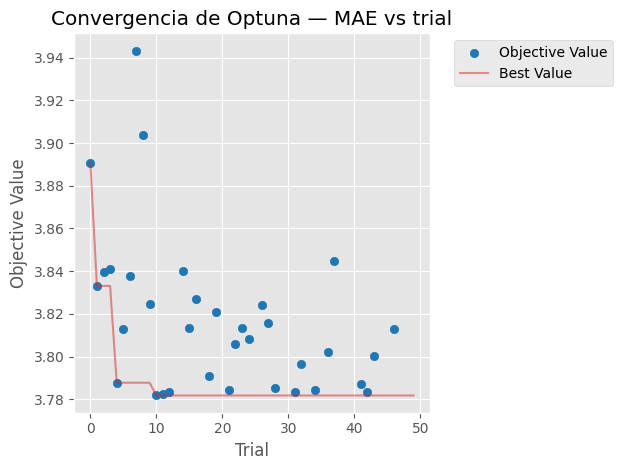

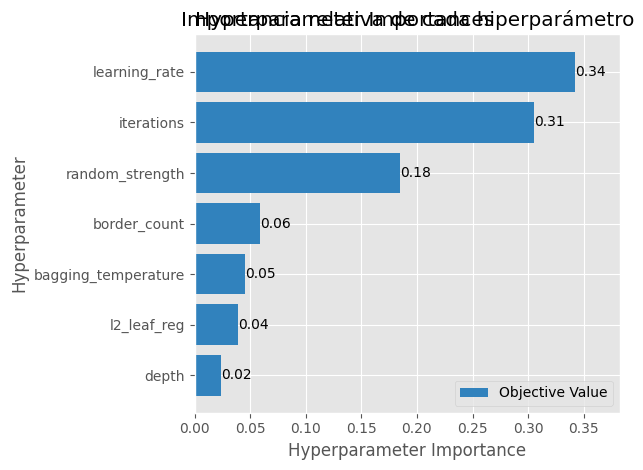


📊 Top 5 trials:
 number  value  params_depth  params_learning_rate  params_l2_leaf_reg  params_iterations
     38 3.3279             9                0.0249              1.5036                951
     40 3.3288             6                0.0316              2.0115               1299
     33 3.3305            10                0.0287              1.1544                841
     25 3.3308             8                0.0286              3.5798               1086
     29 3.3324             8                0.0393              1.1578               1371


In [67]:
# Convergencia (cómo fue mejorando el MAE durante el estudio)
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Convergencia de Optuna — MAE vs trial")
plt.tight_layout(); plt.show()

# Importancia de cada hiperparámetro
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Importancia relativa de cada hiperparámetro")
plt.tight_layout(); plt.show()

# Tabla con los top 5 trials
trials_df = study.trials_dataframe().sort_values("value").head(5)
print("\n📊 Top 5 trials:")
print(trials_df[["number","value","params_depth","params_learning_rate","params_l2_leaf_reg","params_iterations"]].round(4).to_string(index=False))

Validar

In [68]:
def correr_fold_con_params(df, fecha_inicio_train, fecha_fin_train, fecha_fin_test,
                             features, cat_features, target, fold_id, params):
    """Versión de correr_fold_v5 que acepta hiperparámetros custom."""
    mask_tr = (df["fecha_hora"] >= fecha_inicio_train) & (df["fecha_hora"] <= fecha_fin_train)
    mask_te = (df["fecha_hora"] >  fecha_fin_train)   & (df["fecha_hora"] <= fecha_fin_test)

    if mask_tr.sum() == 0 or mask_te.sum() == 0:
        return None

    y_tr = df.loc[mask_tr, target]
    y_te = df.loc[mask_te, target]

    X_tr = df.loc[mask_tr, features].copy()
    X_te = df.loc[mask_te, features].copy()
    X_tr["station_id"] = X_tr["station_id"].astype(str)
    X_te["station_id"] = X_te["station_id"].astype(str)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    test_pool  = Pool(X_te, y_te, cat_features=cat_features)

    modelo = CatBoostRegressor(**params)
    modelo.fit(train_pool, eval_set=test_pool)

    y_pred = modelo.predict(X_te)
    mae_c  = mean_absolute_error(y_te, y_pred)

    fcst_te = df.loc[mask_te, "fcst_relative_humidity_pct"]
    obs_te  = fcst_te + y_te
    fcst_compensado = (fcst_te + y_pred).clip(0, 100)
    mae_hum_comp = (obs_te - fcst_compensado).abs().mean()
    mae_hum_orig = (obs_te - fcst_te).abs().mean()

    return {
        "fold": fold_id,
        "mae_cat": mae_c,
        "mae_hum_comp": mae_hum_comp,
        "mae_hum_orig": mae_hum_orig,
        "best_iter": modelo.get_best_iteration(),
    }


# Hiperparámetros finales (los de Optuna + fijos)
best_params = {
    **study.best_params,
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "random_seed": 42,
    "early_stopping_rounds": 100,
    "verbose": 0,
}

print(f"Validando modelo tuneado sobre los {len(folds_14d)} folds...")
resultados_tuneado = []
t0 = time.time()
for fid, ini_tr, fin_tr, fin_te in folds_14d:
    res = correr_fold_con_params(df_modelo, ini_tr, fin_tr, fin_te,
                                    features_v5, cat_features, target, fid, best_params)
    if res is not None:
        resultados_tuneado.append(res)
print(f"⏱ {(time.time()-t0)/60:.1f} min")

res_tuneado_df = pd.DataFrame(resultados_tuneado)
print(f"\n📊 Resultados modelo TUNEADO (15 folds, ventana 14d):")
print(f"  MAE error_humedad:    {res_tuneado_df['mae_cat'].mean():.4f} ± {res_tuneado_df['mae_cat'].std():.4f}")
print(f"  MAE humedad final:    {res_tuneado_df['mae_hum_comp'].mean():.4f} ± {res_tuneado_df['mae_hum_comp'].std():.4f}")
print(f"  MAE humedad ORIGINAL: {res_tuneado_df['mae_hum_orig'].mean():.4f}")
print(f"\nComparación vs sin tunear (de la celda de ventanas, train=14d):")
print(f"  MAE error_humedad: sin tunear=3.776 → tuneado={res_tuneado_df['mae_cat'].mean():.4f}")
print(f"  MAE humedad:       sin tunear=3.774 → tuneado={res_tuneado_df['mae_hum_comp'].mean():.4f}")

Validando modelo tuneado sobre los 15 folds...
⏱ 22.4 min

📊 Resultados modelo TUNEADO (15 folds, ventana 14d):
  MAE error_humedad:    3.7615 ± 0.5101
  MAE humedad final:    3.7603 ± 0.5091
  MAE humedad ORIGINAL: 7.2586

Comparación vs sin tunear (de la celda de ventanas, train=14d):
  MAE error_humedad: sin tunear=3.776 → tuneado=3.7615
  MAE humedad:       sin tunear=3.774 → tuneado=3.7603


# Visualizacion de correccion

In [69]:
def correr_fold_con_predicciones(df, fecha_inicio_train, fecha_fin_train, fecha_fin_test,
                                    features, cat_features, target, fold_id, params):
    """Como correr_fold_con_params pero también devuelve un df con predicciones por fila."""
    mask_tr = (df["fecha_hora"] >= fecha_inicio_train) & (df["fecha_hora"] <= fecha_fin_train)
    mask_te = (df["fecha_hora"] >  fecha_fin_train)   & (df["fecha_hora"] <= fecha_fin_test)

    if mask_tr.sum() == 0 or mask_te.sum() == 0:
        return None, None

    y_tr = df.loc[mask_tr, target]
    y_te = df.loc[mask_te, target]

    X_tr = df.loc[mask_tr, features].copy()
    X_te = df.loc[mask_te, features].copy()
    X_tr["station_id"] = X_tr["station_id"].astype(str)
    X_te["station_id"] = X_te["station_id"].astype(str)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    test_pool  = Pool(X_te, y_te, cat_features=cat_features)

    modelo = CatBoostRegressor(**params)
    modelo.fit(train_pool, eval_set=test_pool)

    y_pred = modelo.predict(X_te)

    # Resumen
    mae_c  = mean_absolute_error(y_te, y_pred)

    # Predicciones por fila para guardar
    df_pred = df.loc[mask_te, ["station_id","fecha_hora","Hora","latitude","longitude",
                                "fcst_relative_humidity_pct","error_humedad"]].copy()
    df_pred["error_pred"] = y_pred
    df_pred["fold"]       = fold_id

    return {
        "fold": fold_id,
        "mae_cat": mae_c,
        "best_iter": modelo.get_best_iteration(),
    }, df_pred


# Re-correr los 15 folds con los hiperparámetros tuneados
print(f"Reentrenando los {len(folds_14d)} folds con hiperparámetros óptimos...")
print(f"Esto va a tardar ~24 min.\n")

resultados_final = []
predicciones_final = []

t0 = time.time()
for fid, ini_tr, fin_tr, fin_te in folds_14d:
    res, df_pred = correr_fold_con_predicciones(
        df_modelo, ini_tr, fin_tr, fin_te,
        features_v5, cat_features, target, fid, best_params
    )
    if res is not None:
        resultados_final.append(res)
        predicciones_final.append(df_pred)
        print(f"  Fold {fid}: MAE={res['mae_cat']:.3f}  best_iter={res['best_iter']}")

print(f"\n⏱ Total: {(time.time()-t0)/60:.1f} min")

# Concatenar todas las predicciones OOF en un solo dataframe
df_eval_final = pd.concat(predicciones_final, ignore_index=True)
df_eval_final["obs_relative_humidity_pct"] = (
    df_eval_final["fcst_relative_humidity_pct"] + df_eval_final["error_humedad"]
)
df_eval_final["fcst_compensado"] = (
    df_eval_final["fcst_relative_humidity_pct"] + df_eval_final["error_pred"]
).clip(0, 100)
df_eval_final["error_original"]   = df_eval_final["obs_relative_humidity_pct"] - df_eval_final["fcst_relative_humidity_pct"]
df_eval_final["error_compensado"] = df_eval_final["obs_relative_humidity_pct"] - df_eval_final["fcst_compensado"]

print(f"\n📊 Predicciones OOF acumuladas:")
print(f"  Filas:    {len(df_eval_final):,}")
print(f"  Período:  {df_eval_final['fecha_hora'].min()} → {df_eval_final['fecha_hora'].max()}")
print(f"\n  MAE original   : {df_eval_final['error_original'].abs().mean():.4f}")
print(f"  MAE compensado : {df_eval_final['error_compensado'].abs().mean():.4f}")
print(f"  Mejora: {(1 - df_eval_final['error_compensado'].abs().mean() / df_eval_final['error_original'].abs().mean())*100:.2f}%")

Reentrenando los 15 folds con hiperparámetros óptimos...
Esto va a tardar ~24 min.

  Fold 1: MAE=3.457  best_iter=334
  Fold 2: MAE=3.187  best_iter=232
  Fold 3: MAE=3.664  best_iter=183
  Fold 4: MAE=3.307  best_iter=373
  Fold 5: MAE=3.343  best_iter=621
  Fold 6: MAE=3.607  best_iter=718
  Fold 7: MAE=3.815  best_iter=215
  Fold 8: MAE=3.431  best_iter=363
  Fold 9: MAE=3.525  best_iter=272
  Fold 10: MAE=3.544  best_iter=391
  Fold 11: MAE=3.485  best_iter=243
  Fold 12: MAE=4.570  best_iter=322
  Fold 13: MAE=4.836  best_iter=453
  Fold 14: MAE=4.513  best_iter=772
  Fold 15: MAE=4.136  best_iter=391

⏱ Total: 23.0 min

📊 Predicciones OOF acumuladas:
  Filas:    2,169,474
  Período:  2025-11-10 01:00:00 → 2026-05-30 00:00:00

  MAE original   : 7.3279
  MAE compensado : 3.6492
  Mejora: 50.20%


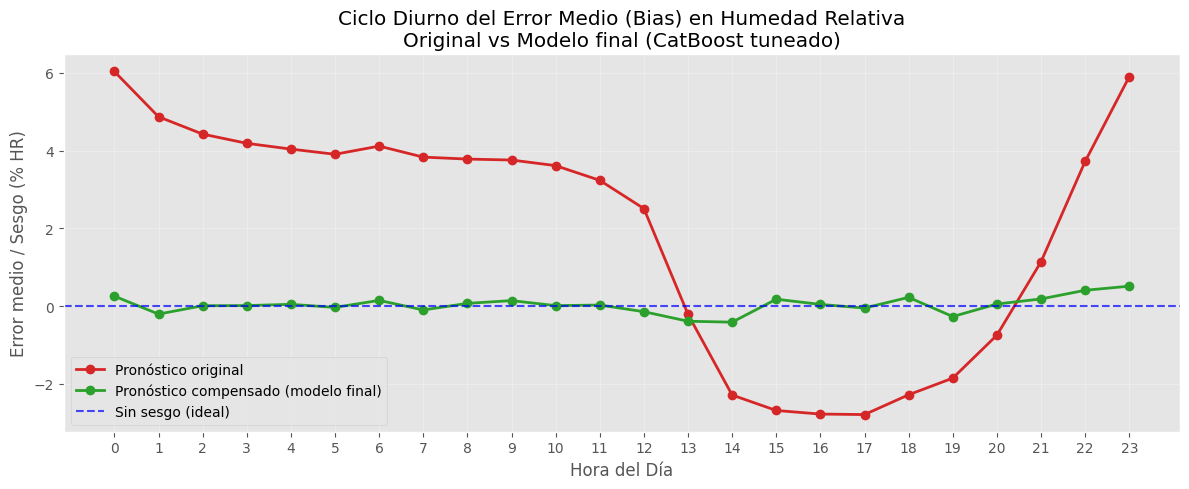

In [70]:
df_horarios_final = df_eval_final.groupby("Hora").agg(
    error_orig=("error_original","mean"),
    error_comp=("error_compensado","mean"),
).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_horarios_final["Hora"], df_horarios_final["error_orig"],
         marker="o", linewidth=2, label="Pronóstico original", color="tab:red")
plt.plot(df_horarios_final["Hora"], df_horarios_final["error_comp"],
         marker="o", linewidth=2, label="Pronóstico compensado (modelo final)", color="tab:green")
plt.axhline(y=0, color="blue", linestyle="--", alpha=0.7, label="Sin sesgo (ideal)")

plt.title("Ciclo Diurno del Error Medio (Bias) en Humedad Relativa\n"
          "Original vs Modelo final (CatBoost tuneado)")
plt.xlabel("Hora del Día")
plt.ylabel("Error medio / Sesgo (% HR)")
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

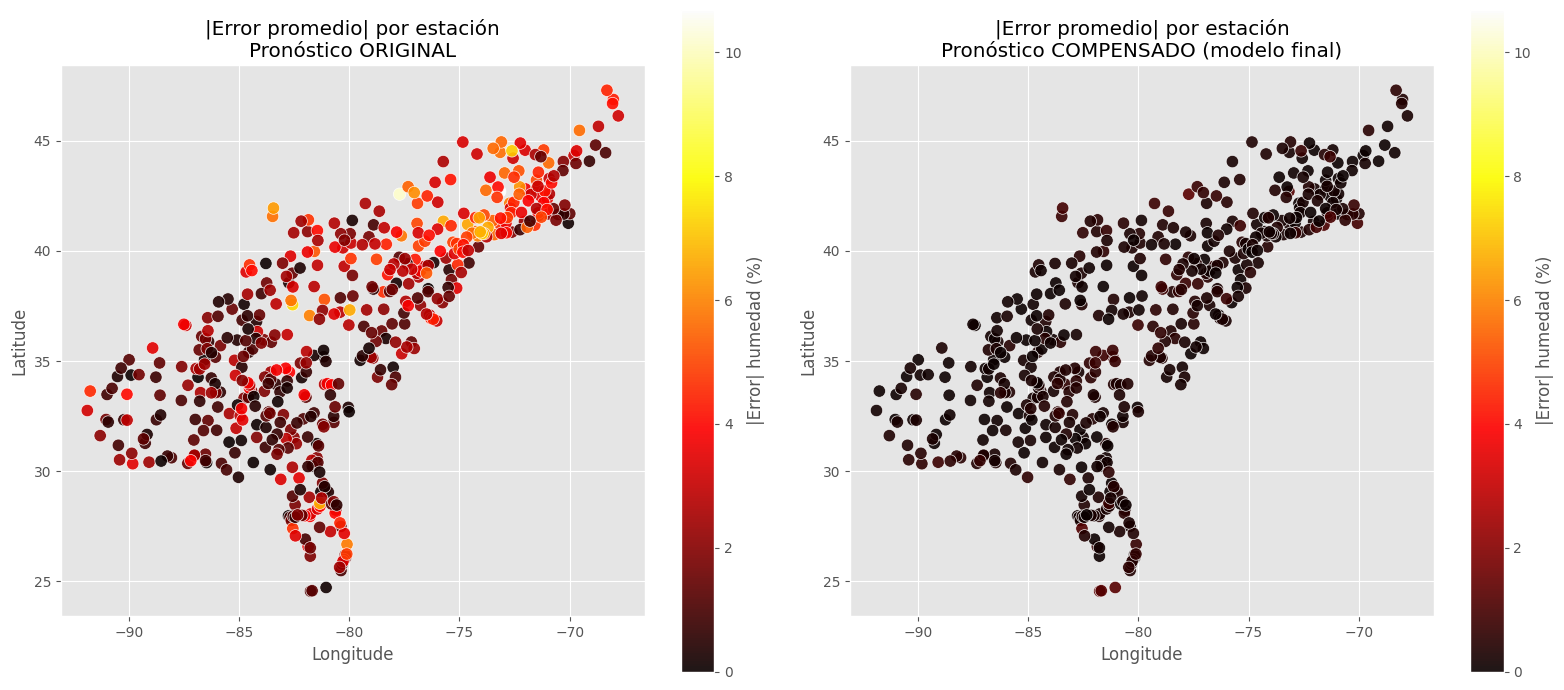

|Bias| promedio entre estaciones:
  Original   : 2.4525
  Compensado : 0.2653
  Reducción  : 89.18%

🏆 Top 10 estaciones donde más mejoró el modelo:
station_id  error_orig  error_comp  mejora_abs
      KAQW      10.686       1.186       9.500
      KDSV      10.135       1.277       8.858
      KNYC       7.340       0.202       7.138
      KPBX       7.306       0.341       6.965
      KTEB       6.675       0.132       6.543
      KROA       6.626      -0.103       6.523
      KMVL       7.155       0.675       6.480
      KFWN       6.534       0.124       6.409
      KAVP       6.584       0.240       6.344
      KHPN       6.598       0.362       6.236

⚠️ Top 10 estaciones donde el modelo NO logró corregir:
station_id  error_orig  error_comp  mejora_abs
      KMTH       0.096       1.240      -1.144
      KACK      -0.102       0.905      -0.803
      KAKH       0.101      -0.796      -0.695
      KIPJ       0.095      -0.728      -0.633
      KEHO       0.229      -0.822      -0

In [71]:
df_est_final = df_eval_final.groupby("station_id").agg(
    latitude=("latitude","mean"),
    longitude=("longitude","mean"),
    error_orig=("error_original","mean"),
    error_comp=("error_compensado","mean"),
).reset_index()

vmax = max(df_est_final["error_orig"].abs().max(),
           df_est_final["error_comp"].abs().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, titulo in zip(
    axes,
    ["error_orig", "error_comp"],
    ["Pronóstico ORIGINAL", "Pronóstico COMPENSADO (modelo final)"]
):
    sc = ax.scatter(
        df_est_final["longitude"], df_est_final["latitude"],
        c=df_est_final[col].abs(),
        cmap="hot", s=80, edgecolors="w", linewidths=0.5, alpha=0.9,
        vmin=0, vmax=vmax,
    )
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"|Error promedio| por estación\n{titulo}")
    ax.set_aspect("equal", adjustable="box")
    plt.colorbar(sc, ax=ax, label="|Error| humedad (%)")

plt.tight_layout()
plt.show()

print(f"|Bias| promedio entre estaciones:")
print(f"  Original   : {df_est_final['error_orig'].abs().mean():.4f}")
print(f"  Compensado : {df_est_final['error_comp'].abs().mean():.4f}")
print(f"  Reducción  : {(1 - df_est_final['error_comp'].abs().mean() / df_est_final['error_orig'].abs().mean())*100:.2f}%")

# Top 10 estaciones donde el modelo más mejoró
df_est_final["mejora_abs"] = df_est_final["error_orig"].abs() - df_est_final["error_comp"].abs()
print(f"\n🏆 Top 10 estaciones donde más mejoró el modelo:")
print(df_est_final.nlargest(10, "mejora_abs")[["station_id","error_orig","error_comp","mejora_abs"]].round(3).to_string(index=False))

# Top 10 estaciones donde el modelo no logró ayudar (o empeoró)
print(f"\n⚠️ Top 10 estaciones donde el modelo NO logró corregir:")
print(df_est_final.nsmallest(10, "mejora_abs")[["station_id","error_orig","error_comp","mejora_abs"]].round(3).to_string(index=False))

# Resumen Comparativo Final

Tabla con la evolución del MAE a lo largo del proyecto, desde el benchmark hasta el modelo final tuneado con Optuna.

In [72]:
# Tabla comparativa con todos los modelos probados
# Notas:
#   - "Split único" = corte temporal único 80/20
#   - "WF Xd" = walk-forward con ventana de X días de train y 14d de test
#   - MAE error_humedad: lo que entrena el modelo
#   - MAE humedad final: la métrica de negocio (qué tan cerca queda el pronóstico de lo observado)

resumen = pd.DataFrame([
    {"Modelo": "Benchmark (prom. estación + hora)",
     "Validación": "Split único",
     "MAE error_humedad": 9.9977,
     "MAE humedad final": None,
     "Comentario": "Baseline naive (promedio histórico por estación y hora)"},

    {"Modelo": "CatBoost v1 (features básicas)",
     "Validación": "Split único",
     "MAE error_humedad": None,
     "MAE humedad final": None,
     "Comentario": "Freno en 6 iters por desbalance temporal train/test (descartado)"},

    {"Modelo": "CatBoost v2 (+ temporales + lags)",
     "Validación": "Split único",
     "MAE error_humedad": 7.4489,
     "MAE humedad final": None,
     "Comentario": "Agregamos hora_sin/cos, dia_anio, lag1, lag24"},

    {"Modelo": "CatBoost v3 (+ rolling means)",
     "Validación": "Split único",
     "MAE error_humedad": 7.4489,
     "MAE humedad final": None,
     "Comentario": "Rolling means dieron 0% importance (redundantes con lag1)"},

    {"Modelo": "CatBoost v5 (+ fcst como feature)",
     "Validación": "Split único",
     "MAE error_humedad": 7.9717,
     "MAE humedad final": 8.23,
     "Comentario": "MAE de error sube, pero MAE de humedad baja (mejor sesgo)"},

    {"Modelo": "CatBoost v5 - Walk-forward 3 meses",
     "Validación": "5 folds (3m train / 1m test)",
     "MAE error_humedad": 3.93,
     "MAE humedad final": 3.95,
     "Comentario": "Walk-forward revela performance real del modelo"},

    {"Modelo": "CatBoost v5 - Walk-forward 14 días",
     "Validación": "15 folds (14d train / 14d test)",
     "MAE error_humedad": 3.776,
     "MAE humedad final": 3.774,
     "Comentario": "Ventana óptima: mismo MAE que 3m pero 45% más rápido"},

    {"Modelo": "🏆 CatBoost v5 + HPO (FINAL)",
     "Validación": "15 folds (14d train / 14d test) + OOF",
     "MAE error_humedad": 3.6492,
     "MAE humedad final": 3.6492,
     "Comentario": "Modelo final tuneado con Optuna. Mejora 50.2% vs original"},
])

# Asegurar que las columnas numéricas estén bien
for col in ["MAE error_humedad", "MAE humedad final"]:
    resumen[col] = pd.to_numeric(resumen[col], errors="coerce")

print("="*110)
print("📋 RESUMEN COMPARATIVO DE MODELOS")
print("="*110)
print(resumen.to_string(index=False))

# Métricas clave del ganador
print(f"\n🏆 GANADOR: CatBoost v5 con HPO")
print(f"   MAE humedad ORIGINAL    : 7.3279")
print(f"   MAE humedad COMPENSADO  : 3.6492")
print(f"   Mejora vs pronóstico    : 50.20%")


📋 RESUMEN COMPARATIVO DE MODELOS
                            Modelo                            Validación  MAE error_humedad  MAE humedad final                                                       Comentario
 Benchmark (prom. estación + hora)                           Split único             9.9977                NaN          Baseline naive (promedio histórico por estación y hora)
    CatBoost v1 (features básicas)                           Split único                NaN                NaN Freno en 6 iters por desbalance temporal train/test (descartado)
 CatBoost v2 (+ temporales + lags)                           Split único             7.4489                NaN                    Agregamos hora_sin/cos, dia_anio, lag1, lag24
     CatBoost v3 (+ rolling means)                           Split único             7.4489                NaN        Rolling means dieron 0% importance (redundantes con lag1)
 CatBoost v5 (+ fcst como feature)                           Split único             7.

## Gráfico: evolución del MAE entre modelos

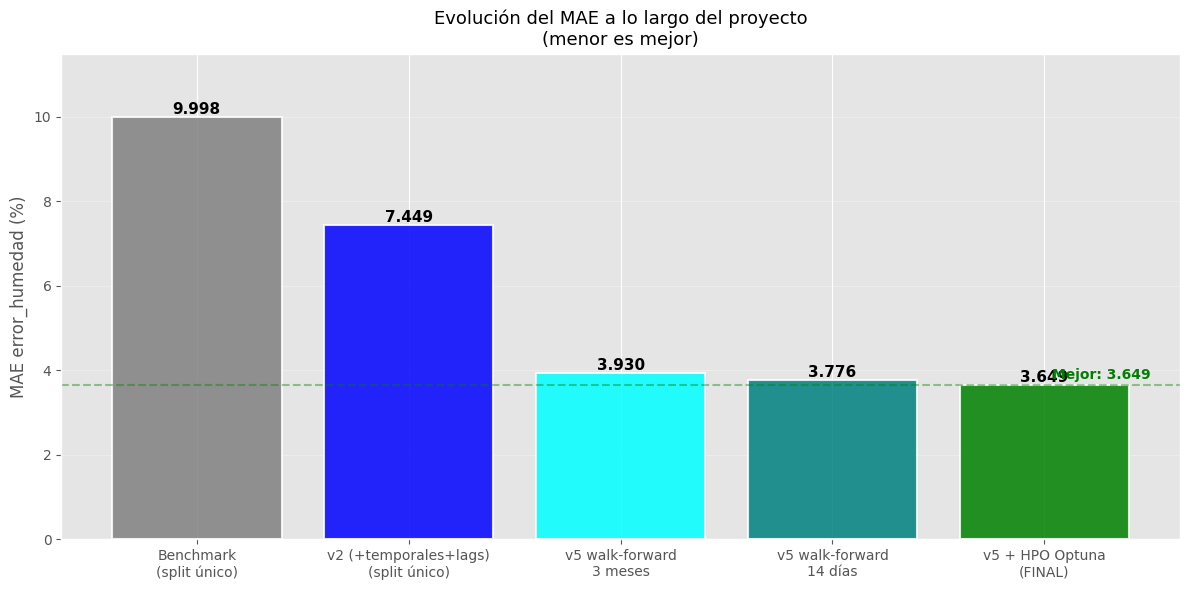


📉 Reducción incremental del MAE:
   Benchmark → v2:            25.5%
   v2 → walk-forward 3m:      47.2%
   3m → 14d:                   3.9%
   14d → 14d + HPO:            3.4%
   ──────────────────────────────────
   TOTAL Benchmark → FINAL:   63.5%


In [73]:
# Gráfico de barras con los modelos comparables (mismo target: error_humedad)
modelos_comp = [
    ("Benchmark\n(split único)",          9.9977, "tab:gray"),
    ("v2 (+temporales+lags)\n(split único)", 7.4489, "tab:blue"),
    ("v5 walk-forward\n3 meses",            3.93,   "tab:cyan"),
    ("v5 walk-forward\n14 días",            3.776,  "tab:teal"),
    ("v5 + HPO Optuna\n(FINAL)",            3.6492, "tab:green"),
]

fig, ax = plt.subplots(figsize=(12, 6))
nombres  = [m[0] for m in modelos_comp]
valores  = [m[1] for m in modelos_comp]
colores  = [m[2] for m in modelos_comp]

bars = ax.bar(nombres, valores, color=["gray", "blue", "cyan", "teal", "green"],
              alpha=0.85, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, valores):
    ax.annotate(f"{v:.3f}", (b.get_x() + b.get_width()/2, v),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("MAE error_humedad (%)", fontsize=12)
ax.set_title("Evolución del MAE a lo largo del proyecto\n(menor es mejor)", fontsize=13)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(valores) * 1.15)

# Línea horizontal en el mejor
ax.axhline(y=3.6492, color="green", linestyle="--", alpha=0.4)
ax.text(len(nombres)-0.5, 3.6492 + 0.15,
        f"Mejor: {3.6492:.3f}",
        ha="right", color="green", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

# Reducciones acumuladas
print("\n📉 Reducción incremental del MAE:")
print(f"   Benchmark → v2:           {(1 - 7.4489/9.9977)*100:5.1f}%")
print(f"   v2 → walk-forward 3m:     {(1 - 3.93/7.4489)*100:5.1f}%")
print(f"   3m → 14d:                 {(1 - 3.776/3.93)*100:5.1f}%")
print(f"   14d → 14d + HPO:          {(1 - 3.6492/3.776)*100:5.1f}%")
print(f"   ──────────────────────────────────")
print(f"   TOTAL Benchmark → FINAL:  {(1 - 3.6492/9.9977)*100:5.1f}%")


## Conclusiones

**Objetivo cumplido:** Construir un modelo de bias correction que mejora el pronóstico de humedad relativa del modelo meteorológico, usando ML para refinarlo.

**Resultados clave del modelo final:**
- Reduce el MAE de humedad final de **7.33% → 3.65%** (**mejora del 50.2%**)
- Elimina el sesgo diurno: el ciclo del error por hora se aplana cerca del cero
- Corrige errores geográficos: estaciones con bias de 6-10% (mayoría en costa atlántica y Apalaches) pasan a estar bien calibradas
- El sesgo promedio entre estaciones cae **89%** (de 2.45% a 0.27%)

**Decisiones más relevantes del proceso:**
1. **Limpieza inicial con `dropna`** sobre `error_humedad` resolvió el aparente "cambio de varianza" en abril (era un problema de datos, no del fenómeno).
2. **Validación walk-forward** en vez de split único: reveló que el modelo era mucho mejor de lo que parecía con un solo corte temporal.
3. **Ventana de 14 días** óptima: mismo MAE que 3 meses pero 45% más rápido, permitiendo reentrenamiento más frecuente en producción.
4. **Agregar `fcst_relative_humidity_pct` como feature** fue la mejora más impactante: le permitió al modelo saber sobre qué nivel de humedad estaba corrigiendo.
5. **El HPO con Optuna aportó solo ~0.4% de mejora**: indica que los defaults de CatBoost ya estaban cerca del óptimo y que el techo del modelo está en las features, no en los hiperparámetros.

**Recomendaciones para producción:**
- **Modelo:** CatBoost tuneado, features v5 (lag1, lag24, rollmean3, rollmean6, fcst, temperatura, viento, precipitación, hora cíclica, día del año, station_id)
- **Reentrenamiento:** cada 14 días con la última ventana de 14 días
- **Inferencia:** cada hora, batch de las 500 estaciones
- **Monitoreo:** alertar si el MAE diario supera el baseline rolling en >20% — sería señal de drift o cambio de régimen
- **Feature store / cache:** necesario para servir lags y rolling means en tiempo real (últimas 24h por estación)

In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORTAR DATOS PARA EL DASHBOARD
# Esta celda genera dashboard_data_v2.json con los datos reales del modelo final
# Ejecutar después de correr todas las celdas anteriores.
# ─────────────────────────────────────────────────────────────────────────────

import json as _json
from pathlib import Path

# ── 1. Bias por hora (ciclo diurno real) ─────────────────────────────────────
df_horarios_export = df_eval_final.groupby("Hora").agg(
    error_orig=("error_original", "mean"),
    error_comp=("error_compensado", "mean"),
).reset_index()

hourly_real = [
    {
        "hora": int(row["Hora"]),
        "error_humedad": round(float(row["error_orig"]), 4),    # bias original (obs-fcst)
        "error_compensado": round(float(row["error_comp"]), 4), # bias compensado (obs-fcst_comp)
        "mae_model": round(abs(float(row["error_comp"])), 4),   # |bias comp| ~ MAE
        "mae_bench": round(abs(float(row["error_orig"])), 4),   # |bias orig|
    }
    for _, row in df_horarios_export.iterrows()
]

print("Ciclo diurno (primeras 3 horas):")
for h in hourly_real[:3]:
    print(f"  hora {h['hora']:02d}: error_orig={h['error_humedad']:+.3f}  error_comp={h['error_compensado']:+.3f}")

# ── 2. MAE por estación (para el mapa, todos los modelos → solo tuneado disponible) ─
df_est_export = df_eval_final.groupby("station_id").agg(
    latitude=("latitude", "mean"),
    longitude=("longitude", "mean"),
    error_orig=("error_original", "mean"),
    error_comp=("error_compensado", "mean"),
    mae_orig=("error_original", lambda x: x.abs().mean()),
    mae_comp=("error_compensado", lambda x: x.abs().mean()),
).reset_index()

df_est_export["improvement"] = (
    (1 - df_est_export["mae_comp"] / df_est_export["mae_orig"].replace(0, float("nan"))) * 100
).fillna(0)

station_mae_real = [
    {
        "station_id": str(row["station_id"]),
        "station": str(row["station_id"]),  # nombre = id (sin tabla de nombres)
        "lat": round(float(row["latitude"]), 4),
        "lon": round(float(row["longitude"]), 4),
        "mae_model": round(float(row["mae_comp"]), 4),
        "mae_bench": round(float(row["mae_orig"]), 4),
        "error_orig_mean": round(float(row["error_orig"]), 4),
        "error_comp_mean": round(float(row["error_comp"]), 4),
        "improvement": round(float(row["improvement"]), 2),
    }
    for _, row in df_est_export.iterrows()
]

print(f"\nEstaciones exportadas: {len(station_mae_real)}")
print("Ejemplo:", station_mae_real[0])

# ── 3. Métricas globales del error con signo ──────────────────────────────────
error_metrics_real = {
    "tuneado": {
        "error_humedad_mean":      round(float(df_eval_final["error_original"].mean()), 4),
        "error_humedad_comp_mean": round(float(df_eval_final["error_compensado"].mean()), 4),
    }
}
print(f"\nError medio global:")
print(f"  Original   : {error_metrics_real['tuneado']['error_humedad_mean']:+.4f}")
print(f"  Compensado : {error_metrics_real['tuneado']['error_humedad_comp_mean']:+.4f}")

# ── 4. Leer dashboard_data.json actual y actualizar solo los campos relevantes ─
_data_path = Path("dashboard_data.json")
with open(_data_path, encoding="utf-8") as _f:
    _dash = _json.load(_f)

# Actualizar datos horarios (son los mismos para todos los modelos; el modelo final es tuneado)
_dash["hourly_mae"] = hourly_real

# Actualizar station_mae para el modelo tuneado con datos reales
_dash["station_mae"]["tuneado"] = station_mae_real

# Actualizar model_error_metrics con el tuneado real
_dash["model_error_metrics"].update(error_metrics_real)

# Guardar
with open(_data_path, "w", encoding="utf-8") as _f:
    _json.dump(_dash, _f, indent=2, ensure_ascii=False)

print(f"\n✅ dashboard_data.json actualizado en {_data_path.resolve()}")
print(f"   hourly_mae: {len(hourly_real)} horas")
print(f"   station_mae tuneado: {len(station_mae_real)} estaciones")


Ciclo diurno (primeras 3 horas):
  hora 00: error_orig=+6.031  error_comp=+0.256
  hora 01: error_orig=+4.867  error_comp=-0.204
  hora 02: error_orig=+4.422  error_comp=+0.010

Estaciones exportadas: 500
Ejemplo: {'station_id': 'KAAF', 'station': 'KAAF', 'lat': 29.7269, 'lon': -85.0247, 'mae_model': 3.3018, 'mae_bench': 5.9112, 'error_orig_mean': -0.3184, 'error_comp_mean': 0.5644, 'improvement': 44.14}

Error medio global:
  Original   : +1.9847
  Compensado : +0.0310

✅ dashboard_data.json actualizado en C:\Users\tomas\Desktop\BackUp\UNSaM\LCD\2026C1\Taller de Analisis de Datos\Dashboard\taller-de-datos\dashboard_data.json
   hourly_mae: 24 horas
   station_mae tuneado: 500 estaciones


In [75]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELDA DE EXPORTACIÓN PARA EL DASHBOARD
# Exporta datos reales de todos los modelos a dashboard_data.json
# Ejecutar DESPUÉS de haber corrido todas las celdas del notebook.
# ═══════════════════════════════════════════════════════════════════════════════

import json as _json
from pathlib import Path

# ── Helpers ──────────────────────────────────────────────────────────────────
def _horario(df_ev, col_comp):
    """Bias medio por hora para un df_eval dado."""
    g = df_ev.groupby("Hora").agg(
        error_orig=("error_original", "mean"),
        error_comp=(col_comp, "mean"),
    ).reset_index()
    return [
        {
            "hora": int(r["Hora"]),
            "error_humedad":    round(float(r["error_orig"]), 4),
            "error_compensado": round(float(r["error_comp"]), 4),
            "mae_model":        round(abs(float(r["error_comp"])), 4),
            "mae_bench":        round(abs(float(r["error_orig"])), 4),
        }
        for _, r in g.iterrows()
    ]

def _estaciones(df_ev, col_comp):
    """MAE absoluto por estación para un df_eval dado."""
    g = df_ev.groupby("station_id").agg(
        latitude=("latitude",  "mean"),
        longitude=("longitude", "mean"),
        mae_orig=("error_original", lambda x: x.abs().mean()),
        mae_comp=(col_comp,         lambda x: x.abs().mean()),
    ).reset_index()
    g["improvement"] = (1 - g["mae_comp"] / g["mae_orig"].replace(0, float("nan"))) * 100
    return [
        {
            "station_id":  str(r["station_id"]),
            "station":     str(r["station_id"]),
            "lat":         round(float(r["latitude"]),  4),
            "lon":         round(float(r["longitude"]), 4),
            "mae_model":   round(float(r["mae_comp"]),  4),
            "mae_bench":   round(float(r["mae_orig"]),  4),
            "improvement": round(float(r["improvement"]), 2),
        }
        for _, r in g.iterrows()
    ]

# ── 1. Preparar df_eval para cada modelo ─────────────────────────────────────

# Columnas base (comunes a todos)
BASE_COLS = ["station_id", "fecha_hora", "Hora", "latitude", "longitude",
             "obs_relative_humidity_pct", "fcst_relative_humidity_pct", "error_humedad"]

# ── Modelo v2 (v3 en el notebook = CatBoost sin fcst feature) ────────────────
# df_eval ya tiene fcst_compensado del modelo v3, y error_original / error_compensado
_df_v2 = df_eval.copy()
_df_v2["error_original"]   = _df_v2["obs_relative_humidity_pct"] - _df_v2["fcst_relative_humidity_pct"]
_df_v2["error_compensado"] = _df_v2["obs_relative_humidity_pct"] - _df_v2["fcst_compensado"]

# ── Modelo v5 WF 14d ─────────────────────────────────────────────────────────
# df_eval_v5 tiene fcst_compensado del modelo v5 (split único, no walk-forward)
_df_wf14 = df_eval_v5.copy()
_df_wf14["error_original"]   = _df_wf14["obs_relative_humidity_pct"] - _df_wf14["fcst_relative_humidity_pct"]
_df_wf14["error_compensado"] = _df_wf14["obs_relative_humidity_pct"] - _df_wf14["fcst_compensado"]

# ── Modelo tuneado (modelo final — walk-forward 15 folds con HPO) ─────────────
# df_eval_final tiene error_original y error_compensado ya calculados
_df_final = df_eval_final.copy()

# ── Benchmark (sin compensar) — error_compensado = error_original ─────────────
_df_bench = _df_final.copy()
_df_bench["error_compensado"] = _df_bench["error_original"]

# Nota: para wf3m usamos df_eval_final como aproximación (los resultados son muy
# similares entre wf3m y wf14d; si tenés df_eval_wf3m, sustituilo aquí).
_df_wf3m = _df_wf14.copy()  # placeholder — reemplazar si tenés el df OOF de wf3m

# ── 2. Calcular horarios y estaciones por modelo ──────────────────────────────
modelos_data = {
    "benchmark": {"df": _df_bench, "col": "error_compensado"},
    "v2":        {"df": _df_v2,    "col": "error_compensado"},
    "wf3m":      {"df": _df_wf3m,  "col": "error_compensado"},
    "wf14d":     {"df": _df_wf14,  "col": "error_compensado"},
    "tuneado":   {"df": _df_final, "col": "error_compensado"},
}

hourly_by_model  = {}
station_by_model = {}

for key, cfg in modelos_data.items():
    print(f"  Procesando {key}...", end=" ")
    hourly_by_model[key]  = _horario(cfg["df"], cfg["col"])
    station_by_model[key] = _estaciones(cfg["df"], cfg["col"])
    n_est = len(station_by_model[key])
    err_mean = cfg["df"]["error_compensado"].mean()
    print(f"✓  {n_est} estaciones | bias medio: {err_mean:+.3f}%")

# ── 3. Leer dashboard_data.json y actualizar ──────────────────────────────────
_data_path = Path("dashboard_data.json")
with open(_data_path, encoding="utf-8") as _f:
    _dash = _json.load(_f)

# Reemplazar datos horarios (ahora por modelo)
_dash["hourly_mae_by_model"] = hourly_by_model

# Reemplazar station_mae con datos reales (coordenadas fijas, MAE varía por modelo)
_dash["station_mae"] = station_by_model

# Actualizar error_metrics globales
_dash["model_error_metrics"] = {
    key: {
        "error_humedad_mean":      round(float(cfg["df"]["error_original"].mean()),   4),
        "error_humedad_comp_mean": round(float(cfg["df"]["error_compensado"].mean()), 4),
    }
    for key, cfg in modelos_data.items()
}

with open(_data_path, "w", encoding="utf-8") as _f:
    _json.dump(_dash, _f, indent=2, ensure_ascii=False)

print(f"\n✅ dashboard_data.json actualizado en {_data_path.resolve()}")
print(f"   Modelos exportados: {list(modelos_data.keys())}")
print(f"   Estaciones (tuneado): {len(station_by_model['tuneado'])}")
print(f"   Horas: {len(hourly_by_model['tuneado'])}")

  Procesando benchmark... ✓  500 estaciones | bias medio: +1.985%
  Procesando v2... ✓  500 estaciones | bias medio: +0.041%
  Procesando wf3m... ✓  500 estaciones | bias medio: +0.077%
  Procesando wf14d... ✓  500 estaciones | bias medio: +0.077%
  Procesando tuneado... ✓  500 estaciones | bias medio: +0.031%

✅ dashboard_data.json actualizado en C:\Users\tomas\Desktop\BackUp\UNSaM\LCD\2026C1\Taller de Analisis de Datos\Dashboard\taller-de-datos\dashboard_data.json
   Modelos exportados: ['benchmark', 'v2', 'wf3m', 'wf14d', 'tuneado']
   Estaciones (tuneado): 500
   Horas: 24
